# 1. Load libraries and set up the notebook

In this notebook, we will train a score-based diffusion model on a 2D S-shaped dataset.

We will use:

$$
s_\theta(x_t,t)
\approx
\nabla_{x_t}\log p_t(x_t)
$$

The model will be a small MLP. Since our data are two-dimensional, we will be able to visualize:

- the clean data distribution;
- the forward noising process;
- the true Gaussian-blob score targets;
- the learned score field;
- later, the reverse generation process.

For reproducibility, we fix all random seeds and create folders for figures and saved model checkpoints.


In [1]:
# ── 1. Load libraries and set up the notebook ─────────────────────────────────

from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split


# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 7

random.seed(SEED)
np.random.seed(SEED)

RNG_DATA = np.random.default_rng(SEED)
RNG_PLOT = np.random.default_rng(SEED + 1)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ── Device ────────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

DTYPE = torch.float32


# ── Output folders ────────────────────────────────────────────────────────────
FIG_DIR = Path("figures_diffusion_mlp")
CKPT_DIR = Path("checkpoints_diffusion_mlp")

FIG_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)


# ── Plot defaults ─────────────────────────────────────────────────────────────
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["font.size"] = 12


# ── Environment check ─────────────────────────────────────────────────────────
print(f"PyTorch version : {torch.__version__}")
print(f"NumPy version   : {np.__version__}")
print(f"Device          : {DEVICE}")
print(f"Data dtype      : {DTYPE}")
print(f"Figure folder   : {FIG_DIR.resolve()}")
print(f"Checkpoint folder: {CKPT_DIR.resolve()}")

PyTorch version : 2.2.2
NumPy version   : 1.26.4
Device          : mps
Data dtype      : torch.float32
Figure folder   : /Users/tiam/github/tiamheydari.github.io/_teaching/Modern_AI/notebooks/Workshop_E.4_diffusion_II/figures_diffusion_mlp
Checkpoint folder: /Users/tiam/github/tiamheydari.github.io/_teaching/Modern_AI/notebooks/Workshop_E.4_diffusion_II/checkpoints_diffusion_mlp


# 2. Create the clean dataset

We will first create a simple two-dimensional S-shaped dataset.

Each clean data point is:

$$
x_0^{(i)} \in \mathbb{R}^2
$$

and the complete dataset is:

$$
\mathcal D
=
\left\{
x_0^{(i)}
\right\}_{i=1}^{N}
$$

This is our clean data distribution. Later, the diffusion forward process will gradually add Gaussian noise to these points.

For now, we only create and visualize the clean S-shaped cloud.

We will standardize the data after splitting it into training, validation, and test sets. This avoids using validation or test information when calculating the normalization statistics.

In [4]:
# ── 2. Create the clean S-shaped dataset ──────────────────────────────────────

# Number of clean data points
N_DATA = 12_000

# Shape parameters
S_WIDTH = 1.15
S_HEIGHT = 1.35
DATA_NOISE_STD = 0.055


def make_s_shape(
    n_samples: int,
    rng: np.random.Generator,
    width: float = 1.15,
    height: float = 1.35,
    noise_std: float = 0.055,
) -> np.ndarray:
    """
    Create a noisy 2D S-shaped point cloud.

    Returns
    -------
    data : np.ndarray, shape (n_samples, 2)
        Clean two-dimensional data points.
    """
    if n_samples <= 0:
        raise ValueError("n_samples must be positive.")

    if noise_std < 0:
        raise ValueError("noise_std must be non-negative.")

    # Parameter along the S-shaped centerline
    u = rng.uniform(-np.pi, np.pi, size=n_samples)

    # Vertical S-shaped curve
    x = -width * np.sin(u)
    y = height * (u / np.pi)

    # Add a small amount of local Gaussian thickness around the curve
    noise = rng.normal(loc=0.0, scale=noise_std, size=(n_samples, 2))

    data = np.column_stack([x, y]) + noise
    return data.astype(np.float32)


# Create the raw clean dataset
data_raw = make_s_shape(
    n_samples=N_DATA,
    rng=RNG_DATA,
    width=S_WIDTH,
    height=S_HEIGHT,
    noise_std=DATA_NOISE_STD,
)

print(f"Raw dataset shape: {data_raw.shape}")
print(f"Coordinate means : {data_raw.mean(axis=0)}")
print(f"Coordinate stds  : {data_raw.std(axis=0)}")

Raw dataset shape: (12000, 2)
Coordinate means : [ 0.01405555 -0.00810954]
Coordinate stds  : [0.81852293 0.7793265 ]


## Visualize the clean data

The plot below is the distribution we want the diffusion model to learn.

At the start of training, the model sees clean points from this S-shaped distribution.

Later, it will see noisy versions of these same points at many different noise levels.

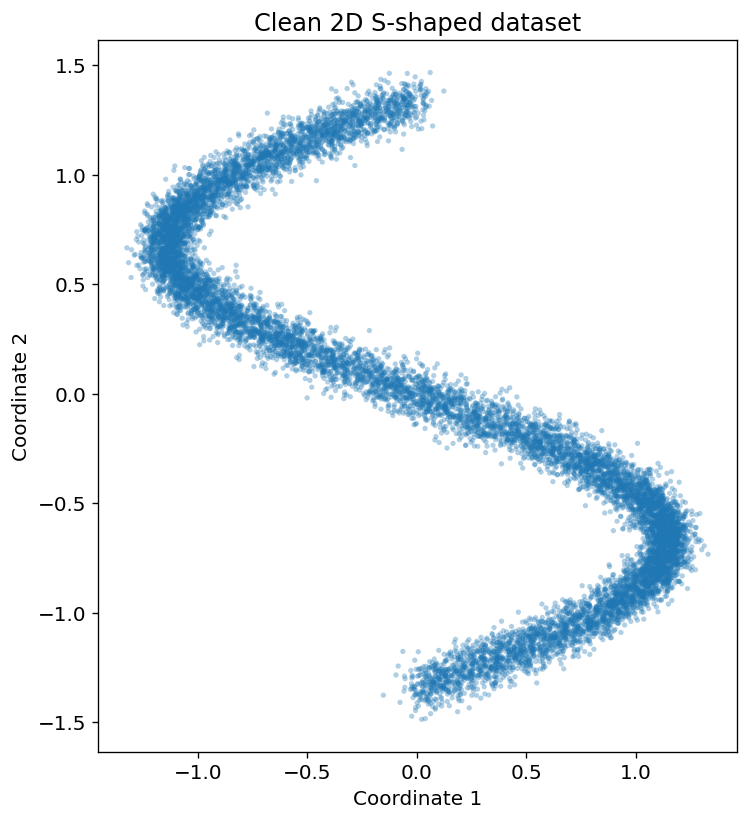

In [5]:
# ── Visualize the clean S-shaped dataset ──────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    data_raw[:, 0],
    data_raw[:, 1],
    s=10,
    alpha=0.35,
    edgecolors="none",
)

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Coordinate 1")
ax.set_ylabel("Coordinate 2")
ax.set_title("Clean 2D S-shaped dataset")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_clean_s_shape_raw.png", bbox_inches="tight")
plt.show()

# 3. Set up the DataLoaders

We now split the clean dataset into three independent parts:

$$
\mathcal D
=
\mathcal D_{\mathrm{train}}
\cup
\mathcal D_{\mathrm{valid}}
\cup
\mathcal D_{\mathrm{test}}
$$

We use:

$$
80\% \text{ training}, \qquad
10\% \text{ validation}, \qquad
10\% \text{ testing}
$$

The training set is used to update the neural-network parameters.

The validation set is used to monitor whether the model is improving on clean points it did not train on.

The test set will remain untouched until the end.

Before training diffusion, we standardize the coordinates using only the training data:

$$
x_0
\leftarrow
\frac{x_0-\mu_{\mathrm{train}}}{\sigma_{\mathrm{train}}}
$$

This makes the training cloud approximately centered around zero with coordinate-wise standard deviation close to one.

That is useful because the forward diffusion process is designed to gradually transform the data distribution into:

$$
\mathcal N(0,I)
$$

In [6]:
# ── 3. Set up train / validation / test DataLoaders ───────────────────────────

# Split settings
TRAIN_FRACTION = 0.80
VALID_FRACTION = 0.10
TEST_FRACTION  = 0.10

BATCH_SIZE = 256

if not np.isclose(TRAIN_FRACTION + VALID_FRACTION + TEST_FRACTION, 1.0):
    raise ValueError("TRAIN_FRACTION, VALID_FRACTION, and TEST_FRACTION must sum to 1.")

if data_raw.ndim != 2 or data_raw.shape[1] != 2:
    raise ValueError(
        f"Expected data_raw with shape (N, 2), but received {data_raw.shape}."
    )

n_total = len(data_raw)
n_train = int(TRAIN_FRACTION * n_total)
n_valid = int(VALID_FRACTION * n_total)
n_test  = n_total - n_train - n_valid

if min(n_train, n_valid, n_test) <= 0:
    raise ValueError(
        "One of the dataset splits is empty. Increase N_DATA or adjust split fractions."
    )

# Deterministic random split
rng_split = np.random.default_rng(SEED + 2)
all_indices = rng_split.permutation(n_total)

train_idx = all_indices[:n_train]
valid_idx = all_indices[n_train:n_train + n_valid]
test_idx  = all_indices[n_train + n_valid:]

data_train_raw = data_raw[train_idx]
data_valid_raw = data_raw[valid_idx]
data_test_raw  = data_raw[test_idx]

# Standardize using training-data statistics only
data_mean = data_train_raw.mean(axis=0, keepdims=True)
data_std  = data_train_raw.std(axis=0, keepdims=True)

if np.any(data_std < 1e-8):
    raise ValueError(
        "At least one coordinate has near-zero standard deviation in the training set."
    )

data_train = ((data_train_raw - data_mean) / data_std).astype(np.float32)
data_valid = ((data_valid_raw - data_mean) / data_std).astype(np.float32)
data_test  = ((data_test_raw  - data_mean) / data_std).astype(np.float32)

# Keep these for converting generated samples back to original coordinates later
DATA_MEAN = data_mean.astype(np.float32)
DATA_STD  = data_std.astype(np.float32)

# Convert to PyTorch datasets
train_dataset = TensorDataset(torch.from_numpy(data_train))
valid_dataset = TensorDataset(torch.from_numpy(data_valid))
test_dataset  = TensorDataset(torch.from_numpy(data_test))

# DataLoaders return batches of clean points x_0
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
)

print("Dataset split sizes")
print(f"  Train      : {len(train_dataset):,}")
print(f"  Validation : {len(valid_dataset):,}")
print(f"  Test       : {len(test_dataset):,}")

print("\nTraining-data normalization statistics")
print(f"  Mean before standardization : {DATA_MEAN.ravel()}")
print(f"  Std before standardization  : {DATA_STD.ravel()}")

print("\nStandardized training-data statistics")
print(f"  Mean after standardization  : {data_train.mean(axis=0)}")
print(f"  Std after standardization   : {data_train.std(axis=0)}")

Dataset split sizes
  Train      : 9,600
  Validation : 1,200
  Test       : 1,200

Training-data normalization statistics
  Mean before standardization : [ 0.01503802 -0.00724491]
  Std before standardization  : [0.8167903 0.7790838]

Standardized training-data statistics
  Mean after standardization  : [5.2675606e-08 3.0423205e-08]
  Std after standardization   : [0.99999875 1.0000005 ]


## Visualize the dataset splits and standardization

The first panel shows that all three splits come from the same S-shaped distribution.

The second panel shows the standardized training data. This standardized space is the coordinate system in which we will train the diffusion model.

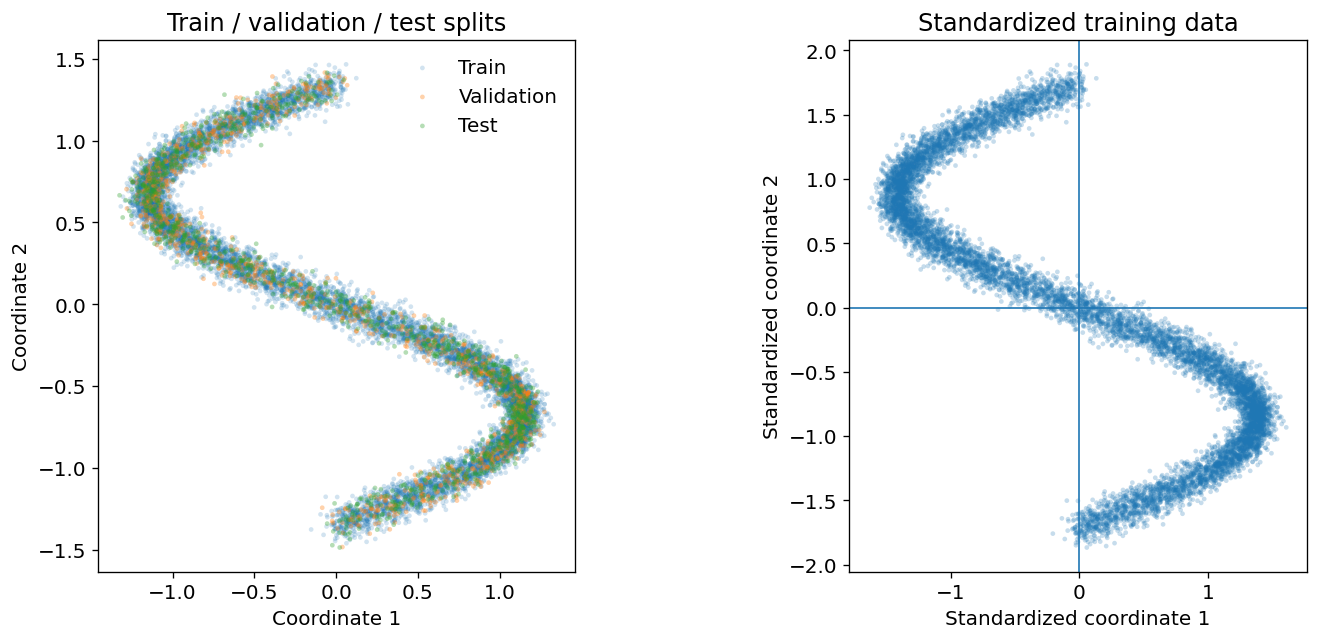

In [7]:
# ── Visualize splits and standardized training data ───────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Original-coordinate dataset splits
axes[0].scatter(
    data_train_raw[:, 0],
    data_train_raw[:, 1],
    s=8,
    alpha=0.20,
    label="Train",
    edgecolors="none",
)

axes[0].scatter(
    data_valid_raw[:, 0],
    data_valid_raw[:, 1],
    s=8,
    alpha=0.35,
    label="Validation",
    edgecolors="none",
)

axes[0].scatter(
    data_test_raw[:, 0],
    data_test_raw[:, 1],
    s=8,
    alpha=0.35,
    label="Test",
    edgecolors="none",
)

axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlabel("Coordinate 1")
axes[0].set_ylabel("Coordinate 2")
axes[0].set_title("Train / validation / test splits")
axes[0].legend(frameon=False)

# Standardized training data
axes[1].scatter(
    data_train[:, 0],
    data_train[:, 1],
    s=8,
    alpha=0.25,
    edgecolors="none",
)

axes[1].axhline(0, linewidth=1)
axes[1].axvline(0, linewidth=1)

axes[1].set_aspect("equal", adjustable="box")
axes[1].set_xlabel("Standardized coordinate 1")
axes[1].set_ylabel("Standardized coordinate 2")
axes[1].set_title("Standardized training data")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_dataset_splits_and_standardization.png", bbox_inches="tight")
plt.show()

## Sanity-check one mini-batch

The DataLoader returns only clean data points.

For one mini-batch of size $B$:

$$
x_0 \in \mathbb R^{B\times 2}
$$

The forward diffusion process will later choose a different random noise level and a different Gaussian noise vector for every point in this batch.

In [8]:
# ── Sanity-check one mini-batch ───────────────────────────────────────────────

x0_batch = next(iter(train_loader))[0]

print(f"Mini-batch shape : {tuple(x0_batch.shape)}")
print(f"Mini-batch dtype : {x0_batch.dtype}")
print(f"Mini-batch device: {x0_batch.device}")

if x0_batch.ndim != 2 or x0_batch.shape[1] != 2:
    raise RuntimeError(
        f"Expected one mini-batch with shape (B, 2), but received {tuple(x0_batch.shape)}."
    )

Mini-batch shape : (256, 2)
Mini-batch dtype : torch.float32
Mini-batch device: cpu


# 4. Define the fixed forward process

We now define the fixed process that gradually transforms clean data into Gaussian noise.

At time $t=0$, we have a clean data point:

$$
x_0
$$

We choose a total of $T$ noise levels and a fixed schedule:

$$
\{\beta_t\}_{t=1}^{T}
$$

At each level:

$$
\alpha_t = 1-\beta_t
$$

and the total amount of original signal remaining after $t$ steps is:

$$
\bar\alpha_t
=
\prod_{s=1}^{t}\alpha_s
$$

Instead of simulating all previous steps every time, we can directly create a noisy version of a clean point at any chosen noise level:

$$
x_t
=
\sqrt{\bar\alpha_t}\,x_0
+
\sqrt{1-\bar\alpha_t}\,\epsilon
$$

where:

$$
\epsilon \sim \mathcal N(0,I)
$$

This equation says:

$$
\text{noisy point}
=
\text{remaining signal}
+
\text{Gaussian noise}
$$

During training, every data point in a mini-batch will receive its own randomly chosen noise level $t$ and its own Gaussian noise vector $\epsilon$.

For now, we define the schedule and verify that the forward process gradually transforms the S-shaped cloud into a standard Gaussian cloud.

In [9]:
# ── 4. Define the fixed forward process ───────────────────────────────────────

# ── 4.1 Choose the number of noise levels and the beta schedule ───────────────
T = 1000

BETA_MIN = 1e-4
BETA_MAX = 2e-2

if T < 2:
    raise ValueError("T must be at least 2.")

if not (0.0 < BETA_MIN < 1.0):
    raise ValueError("BETA_MIN must be between 0 and 1.")

if not (0.0 < BETA_MAX < 1.0):
    raise ValueError("BETA_MAX must be between 0 and 1.")

if BETA_MIN > BETA_MAX:
    raise ValueError("BETA_MIN must be less than or equal to BETA_MAX.")


# We use indices t = 0, 1, ..., T.
# At t = 0, there is no noise, so beta_0 = 0 and alpha_bar_0 = 1.
BETA = torch.zeros(T + 1, dtype=DTYPE, device=DEVICE)
BETA[1:] = torch.linspace(BETA_MIN, BETA_MAX, T, dtype=DTYPE, device=DEVICE)

ALPHA = 1.0 - BETA
ALPHA[0] = 1.0

ALPHA_BAR = torch.cumprod(ALPHA, dim=0)

SQRT_ALPHA_BAR = torch.sqrt(ALPHA_BAR)
SQRT_ONE_MINUS_ALPHA_BAR = torch.sqrt(
    torch.clamp(1.0 - ALPHA_BAR, min=0.0)
)


# ── Helper: extract one schedule value for every example in a batch ───────────
def extract_schedule_value(values, t, x):
    """
    Extract schedule values at batch-specific time indices.

    Parameters
    ----------
    values : torch.Tensor, shape (T + 1,)
        A schedule such as ALPHA_BAR or SQRT_ALPHA_BAR.
    t : torch.Tensor, shape (B,)
        Integer time indices in {0, ..., T}.
    x : torch.Tensor, shape (B, ...)
        Reference tensor used only to determine output shape.

    Returns
    -------
    torch.Tensor, shape (B, 1, ..., 1)
        One schedule value per batch example, broadcastable with x.
    """
    if not isinstance(t, torch.Tensor):
        raise TypeError("t must be a torch.Tensor.")

    if t.ndim != 1:
        raise ValueError(
            f"t must have shape (B,), but received shape {tuple(t.shape)}."
        )

    if t.shape[0] != x.shape[0]:
        raise ValueError(
            "The batch size of t must match the batch size of x. "
            f"Received {t.shape[0]} and {x.shape[0]}."
        )

    t = t.to(device=values.device, dtype=torch.long)

    if torch.any(t < 0) or torch.any(t > T):
        raise ValueError(f"All time indices must be between 0 and {T}.")

    out = values.gather(dim=0, index=t)

    broadcast_shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    return out.reshape(broadcast_shape)


# ── 4.2 Directly create x_t from x_0 ─────────────────────────────────────────
def q_sample(x0, t, eps=None):
    """
    Create noisy samples x_t from clean samples x_0.

    Uses:

        x_t = sqrt(alpha_bar_t) * x_0
            + sqrt(1 - alpha_bar_t) * epsilon

    Parameters
    ----------
    x0 : torch.Tensor, shape (B, ...)
        Clean batch of data points.
    t : torch.Tensor, shape (B,)
        One discrete noise level per batch example.
    eps : torch.Tensor or None, shape (B, ...)
        Gaussian noise. If None, fresh Gaussian noise is sampled.

    Returns
    -------
    xt : torch.Tensor, shape (B, ...)
        Noisy batch at the requested times.
    eps : torch.Tensor, shape (B, ...)
        The Gaussian noise used to create xt.
    """
    if not torch.is_floating_point(x0):
        raise TypeError("x0 must be a floating-point tensor.")

    if eps is None:
        eps = torch.randn_like(x0)

    if eps.shape != x0.shape:
        raise ValueError(
            f"eps must have the same shape as x0. "
            f"Received eps={tuple(eps.shape)}, x0={tuple(x0.shape)}."
        )

    sqrt_alpha_bar_t = extract_schedule_value(SQRT_ALPHA_BAR, t, x0)
    sqrt_one_minus_alpha_bar_t = extract_schedule_value(
        SQRT_ONE_MINUS_ALPHA_BAR,
        t,
        x0,
    )

    xt = sqrt_alpha_bar_t * x0 + sqrt_one_minus_alpha_bar_t * eps

    return xt, eps


# ── Schedule sanity checks ────────────────────────────────────────────────────
alpha_bar_T = ALPHA_BAR[T].item()

print(f"T                 : {T}")
print(f"beta_1            : {BETA[1].item():.6f}")
print(f"beta_T            : {BETA[T].item():.6f}")
print(f"alpha_bar_0       : {ALPHA_BAR[0].item():.6f}")
print(f"alpha_bar_T       : {alpha_bar_T:.8f}")
print(f"signal left at T  : {np.sqrt(alpha_bar_T):.6f}")
print(f"noise weight at T : {np.sqrt(1.0 - alpha_bar_T):.6f}")

if alpha_bar_T > 1e-2:
    print(
        "\nWarning: alpha_bar_T is not very small. "
        "The final noisy cloud may retain visible structure from the data."
    )
else:
    print(
        "\nGood: alpha_bar_T is small, so the terminal distribution is close to N(0, I)."
    )

T                 : 1000
beta_1            : 0.000100
beta_T            : 0.020000
alpha_bar_0       : 1.000000
alpha_bar_T       : 0.00004036
signal left at T  : 0.006353
noise weight at T : 0.999980

Good: alpha_bar_T is small, so the terminal distribution is close to N(0, I).


### Visualize the forward noising process


Each panel below shows the distribution of noisy points at one time level.

For each panel, we use:

$$
x_t
=
\sqrt{\bar\alpha_t}\,x_0
+
\sqrt{1-\bar\alpha_t}\,\epsilon
$$

with newly sampled Gaussian noise.

These are snapshots of the distribution at different noise levels. They are not trajectories of the same individual particles.

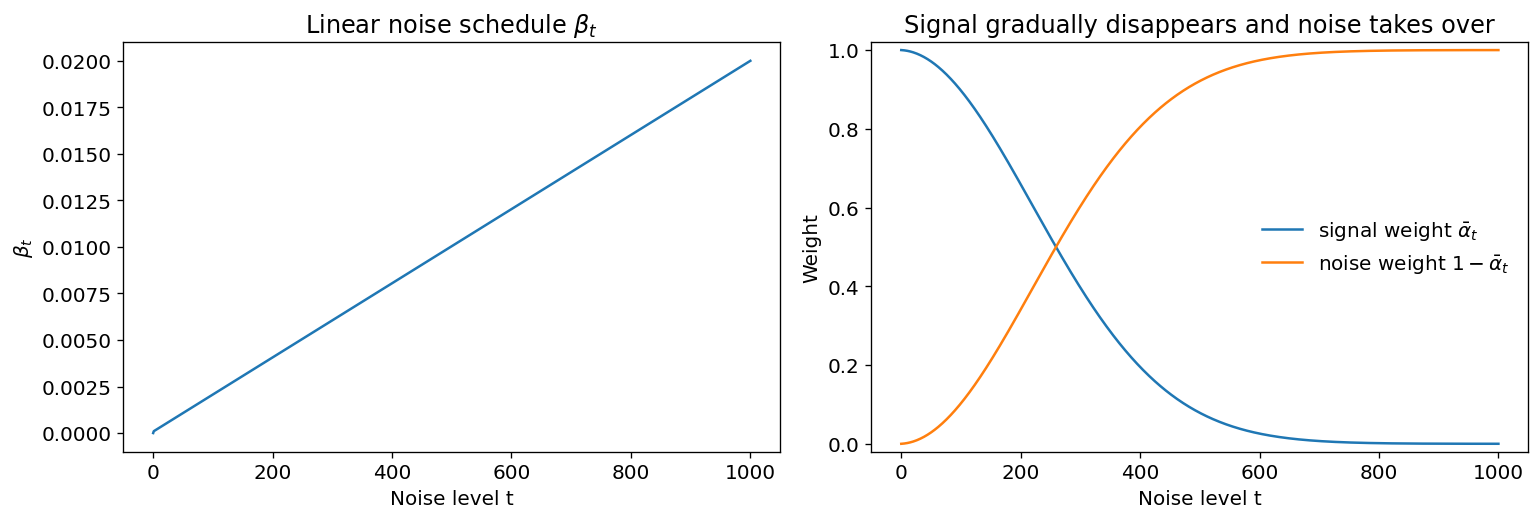

In [11]:
# ── Visualize the forward schedule ────────────────────────────────────────────

t_axis = np.arange(T + 1)

alpha_bar_np = ALPHA_BAR.detach().cpu().numpy()
noise_weight_np = 1.0 - alpha_bar_np
beta_np = BETA.detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(t_axis, beta_np)
axes[0].set_xlabel("Noise level t")
axes[0].set_ylabel(r"$\beta_t$")
axes[0].set_title(r"Linear noise schedule $\beta_t$")

axes[1].plot(t_axis, alpha_bar_np, label=r"signal weight $\bar\alpha_t$")
axes[1].plot(t_axis, noise_weight_np, label=r"noise weight $1-\bar\alpha_t$")
axes[1].set_xlabel("Noise level t")
axes[1].set_ylabel("Weight")
axes[1].set_ylim(-0.02, 1.02)
axes[1].set_title("Signal gradually disappears and noise takes over")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig(FIG_DIR / "03_forward_schedule.png", bbox_inches="tight")
plt.show()

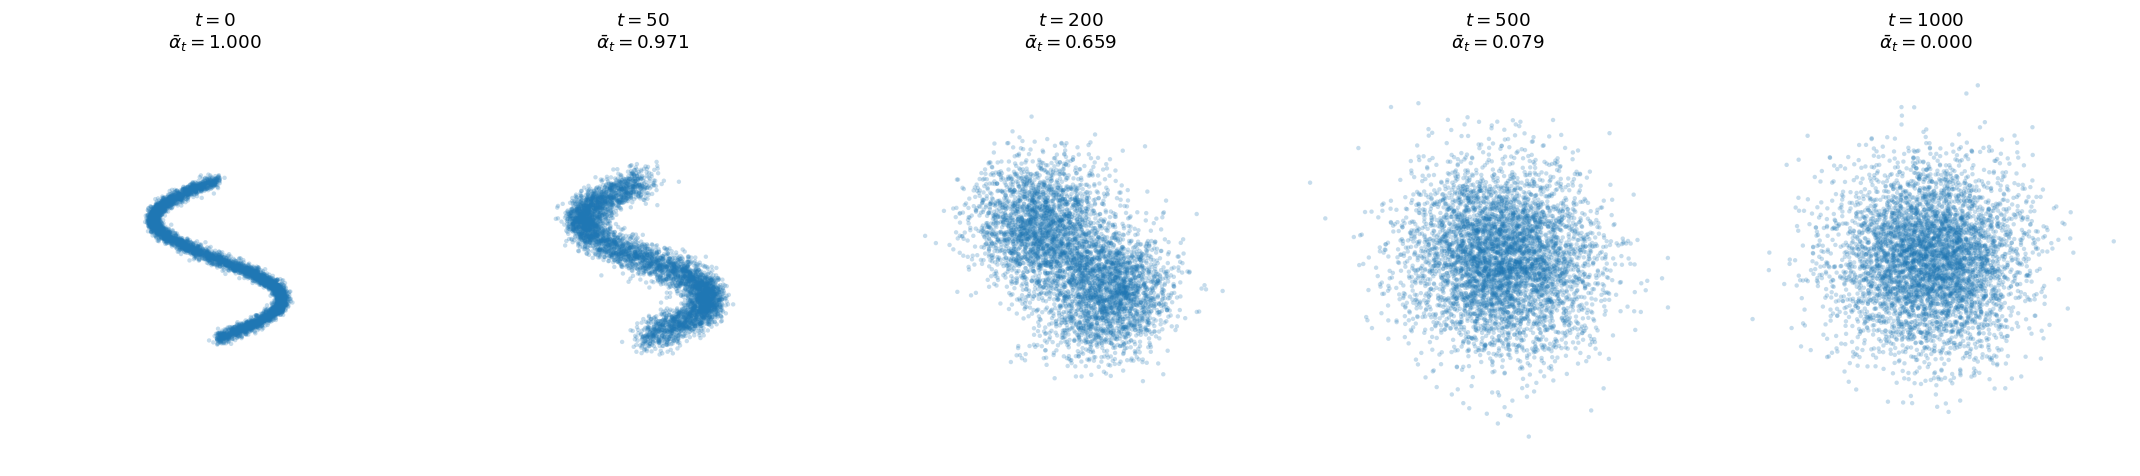

Terminal noisy cloud statistics
  Mean: [ 0.0127748  -0.00018707]
  Std : [1.0033284 1.0075887]

For a successful VP forward process, these should be close to:
  Mean: [0, 0]
  Std : [1, 1]


In [12]:
# ── Visualize forward noising at several times ─────────────────────────────────

SNAP_TIMES = [0, 50, 200, 500, T]
N_VIS = min(5_000, len(data_train))

if len(SNAP_TIMES) != 5:
    raise ValueError("This visualization expects exactly five snapshot times.")

if any(t < 0 or t > T for t in SNAP_TIMES):
    raise ValueError(f"All SNAP_TIMES must be between 0 and {T}.")

# Select a fixed subset of clean training data for visualization
vis_indices = RNG_PLOT.choice(
    len(data_train),
    size=N_VIS,
    replace=False,
)

x0_vis = torch.from_numpy(data_train[vis_indices]).to(
    device=DEVICE,
    dtype=DTYPE,
)

forward_snapshots = {}

with torch.no_grad():
    for t_value in SNAP_TIMES:
        t_batch = torch.full(
            (N_VIS,),
            fill_value=t_value,
            dtype=torch.long,
            device=DEVICE,
        )

        xt_vis, _ = q_sample(x0_vis, t_batch)

        forward_snapshots[t_value] = xt_vis.detach().cpu().numpy()

# Use the same plotting limits in every panel
all_points = np.vstack([forward_snapshots[t] for t in SNAP_TIMES])

x_min, y_min = all_points.min(axis=0)
x_max, y_max = all_points.max(axis=0)

center_x = 0.5 * (x_min + x_max)
center_y = 0.5 * (y_min + y_max)

half_range = 0.5 * max(x_max - x_min, y_max - y_min)
half_range *= 1.08

x_limits = (center_x - half_range, center_x + half_range)
y_limits = (center_y - half_range, center_y + half_range)

fig, axes = plt.subplots(1, len(SNAP_TIMES), figsize=(18, 4))

for ax, t_value in zip(axes, SNAP_TIMES):
    points = forward_snapshots[t_value]

    alpha_bar_value = ALPHA_BAR[t_value].item()

    ax.scatter(
        points[:, 0],
        points[:, 1],
        s=7,
        alpha=0.25,
        edgecolors="none",
    )

    ax.set_xlim(*x_limits)
    ax.set_ylim(*y_limits)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(
        rf"$t={t_value}$" + "\n" + rf"$\bar{{\alpha}}_t={alpha_bar_value:.3f}$",
        fontsize=11,
    )

plt.tight_layout()
plt.savefig(FIG_DIR / "04_forward_noising_snapshots.png", bbox_inches="tight")
plt.show()


# ── Terminal-distribution sanity check ────────────────────────────────────────
xT_vis = forward_snapshots[T]

print("Terminal noisy cloud statistics")
print(f"  Mean: {xT_vis.mean(axis=0)}")
print(f"  Std : {xT_vis.std(axis=0)}")
print("\nFor a successful VP forward process, these should be close to:")
print("  Mean: [0, 0]")
print("  Std : [1, 1]")

# 5. Build the score neural network

We now build a neural network that takes a noisy point and its noise level as input:

$$
(x_t,t)
$$

and outputs a two-dimensional vector:

$$
s_\theta(x_t,t)
\in
\mathbb R^2
$$

Our goal is for this vector to approximate the score of the noisy data distribution:

$$
s_\theta(x_t,t)
\approx
\nabla_{x_t}\log p_t(x_t)
$$

Because our data are two-dimensional, the network output is also two-dimensional: it is an arrow with one component for each coordinate.

We give the MLP three inputs:

$$
\left[
x_{t,1},
x_{t,2},
\frac{t}{T}
\right]
\in
\mathbb R^3
$$

The time is normalized so that:

$$
\frac{t}{T}
\in
[0,1]
$$

The network outputs:

$$
s_\theta(x_t,t)
=
\left[
s_{\theta,1}(x_t,t),
s_{\theta,2}(x_t,t)
\right]
$$

We use a small MLP with SiLU nonlinearities.

There is no activation function on the final layer because score-vector components can be positive, negative, small, or large.

In [14]:
# ── 5. Build the score neural network ────────────────────────────────────────

HIDDEN_DIM = 128
N_HIDDEN_LAYERS = 3


class ScoreMLP(nn.Module):
    """
    MLP that predicts a 2D score vector s_theta(x_t, t).

    Input:
        x_t : shape (B, 2)
        t   : shape (B,)

    Output:
        score : shape (B, 2)
    """

    def __init__(
        self,
        hidden_dim: int,
        n_hidden_layers: int,
        num_timesteps: int,
    ):
        super().__init__()

        if hidden_dim <= 0:
            raise ValueError("hidden_dim must be positive.")

        if n_hidden_layers <= 0:
            raise ValueError("n_hidden_layers must be positive.")

        if num_timesteps <= 0:
            raise ValueError("num_timesteps must be positive.")

        self.num_timesteps = float(num_timesteps)

        # Input:
        # [x_t coordinate 1, x_t coordinate 2, normalized time t / T]
        input_dim = 3
        output_dim = 2

        layers = []
        current_dim = input_dim

        for _ in range(n_hidden_layers):
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.SiLU())
            current_dim = hidden_dim

        # No output activation:
        # a score-vector component must be able to take any real value.
        layers.append(nn.Linear(current_dim, output_dim))

        self.network = nn.Sequential(*layers)

    def forward(self, x_t: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Predict score vectors for a batch of noisy points.

        Parameters
        ----------
        x_t : torch.Tensor, shape (B, 2)
            Noisy data points.

        t : torch.Tensor, shape (B,)
            Integer noise-level indices.

        Returns
        -------
        score : torch.Tensor, shape (B, 2)
            Predicted score vectors.
        """
        if x_t.ndim != 2 or x_t.shape[1] != 2:
            raise ValueError(
                "x_t must have shape (B, 2), "
                f"but received {tuple(x_t.shape)}."
            )

        if t.ndim != 1:
            raise ValueError(
                "t must have shape (B,), "
                f"but received {tuple(t.shape)}."
            )

        if t.shape[0] != x_t.shape[0]:
            raise ValueError(
                "x_t and t must have the same batch size. "
                f"Received {x_t.shape[0]} and {t.shape[0]}."
            )

        # Convert discrete time indices t = 0, ..., T into values in [0, 1].
        t_normalized = (
            t.to(device=x_t.device, dtype=x_t.dtype) / self.num_timesteps
        ).unsqueeze(dim=1)

        # Shape: (B, 3)
        model_input = torch.cat([x_t, t_normalized], dim=1)

        # Shape: (B, 2)
        return self.network(model_input)


# Create the score model
score_model = ScoreMLP(
    hidden_dim=HIDDEN_DIM,
    n_hidden_layers=N_HIDDEN_LAYERS,
    num_timesteps=T,
).to(device=DEVICE, dtype=DTYPE)

print(score_model)

ScoreMLP(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): SiLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): SiLU()
    (6): Linear(in_features=128, out_features=2, bias=True)
  )
)


## Check the input and output shapes

For one mini-batch:

$$
x_t
\in
\mathbb R^{B\times2}
$$

and:

$$
t
\in
\{0,\ldots,T\}^{B}
$$

The MLP should return one score-vector prediction per noisy point:

$$
s_\theta(x_t,t)
\in
\mathbb R^{B\times2}
$$

At this point, the network is untrained, so its output arrows are random. We only check that the shapes are correct and that gradients can flow through the model.

In [15]:
# ── Sanity-check the score-network inputs and outputs ─────────────────────────

# Take clean points from the DataLoader.
x0_batch = next(iter(train_loader))[0].to(device=DEVICE, dtype=DTYPE)

batch_size = x0_batch.shape[0]

# Give every point in this demonstration batch a random noise level.
t_demo = torch.randint(
    low=0,
    high=T + 1,
    size=(batch_size,),
    device=DEVICE,
    dtype=torch.long,
)

# Create corresponding noisy points.
x_t_demo, _ = q_sample(x0_batch, t_demo)

# Ask the untrained MLP for score-vector predictions.
score_demo = score_model(x_t_demo, t_demo)

print(f"x_0 batch shape       : {tuple(x0_batch.shape)}")
print(f"t batch shape         : {tuple(t_demo.shape)}")
print(f"x_t batch shape       : {tuple(x_t_demo.shape)}")
print(f"score output shape    : {tuple(score_demo.shape)}")
print(f"score output dtype    : {score_demo.dtype}")
print(f"score output device   : {score_demo.device}")

if score_demo.shape != x_t_demo.shape:
    raise RuntimeError(
        "The score model should output one 2D vector for every 2D input point."
    )

if not torch.isfinite(score_demo).all():
    raise RuntimeError("The score model produced non-finite values.")

n_parameters = sum(parameter.numel() for parameter in score_model.parameters())

print(f"\nTrainable parameters: {n_parameters:,}")
print("\nFirst five untrained score-vector predictions:")
print(score_demo[:5].detach().cpu())

x_0 batch shape       : (256, 2)
t batch shape         : (256,)
x_t batch shape       : (256, 2)
score output shape    : (256, 2)
score output dtype    : torch.float32
score output device   : mps:0

Trainable parameters: 33,794

First five untrained score-vector predictions:
tensor([[ 0.0427, -0.0397],
        [ 0.0625, -0.0591],
        [ 0.0593, -0.0366],
        [ 0.0460, -0.0382],
        [ 0.0579, -0.0529]])


# 6. Calculate the known score target for a mini-batch

For each clean point in the mini-batch, we independently choose a noise level:

$$
t^{(b)}
\sim
\mathrm{Uniform}\{1,\ldots,T\}
$$

and Gaussian noise:

$$
\epsilon^{(b)}
\sim
\mathcal N(0,I)
$$

We then create its noisy version:

$$
x_{t^{(b)}}^{(b)}
=
\sqrt{\bar\alpha_{t^{(b)}}}\,x_0^{(b)}
+
\sqrt{1-\bar\alpha_{t^{(b)}}}\,\epsilon^{(b)}
$$

For this particular clean point $x_0^{(b)}$, the noisy point comes from a known Gaussian blob:

$$
p_{t^{(b)}}\left(
x_{t^{(b)}}^{(b)}
\mid
x_0^{(b)}
\right)
=
\mathcal N
\left(
\sqrt{\bar\alpha_{t^{(b)}}}\,x_0^{(b)},
\,
\left(1-\bar\alpha_{t^{(b)}}\right)I
\right)
$$

The score of this Gaussian blob is known exactly:

$$
a^{(b)}
=
\nabla_{x_{t^{(b)}}^{(b)}}
\log
p_{t^{(b)}}
\left(
x_{t^{(b)}}^{(b)}
\mid
x_0^{(b)}
\right)
=
\frac{
\sqrt{\bar\alpha_{t^{(b)}}}\,x_0^{(b)}
-
x_{t^{(b)}}^{(b)}
}{
1-\bar\alpha_{t^{(b)}}
}
$$

This is the target arrow used for training.

It is important that this is the score of one known conditional Gaussian blob, not yet the score of the full noisy S-shaped cloud.

We sample times from $1$ to $T$, not from $0$ to $T$, because at:

$$
t=0
$$

the conditional Gaussian has zero variance, so the score-target formula is not defined.

In [16]:
# ── 6. Calculate the known conditional Gaussian-blob score target ────────────

# We will use this in the loss function in Section 7.
ONE_MINUS_ALPHA_BAR = 1.0 - ALPHA_BAR


def conditional_score_target(
    x0: torch.Tensor,
    xt: torch.Tensor,
    t: torch.Tensor,
) -> torch.Tensor:
    """
    Calculate the known conditional Gaussian-blob score target.

    For:

        p_t(x_t | x_0)
        =
        N(
            sqrt(alpha_bar_t) * x_0,
            (1 - alpha_bar_t) * I
        )

    the score with respect to x_t is:

        grad_{x_t} log p_t(x_t | x_0)
        =
        [sqrt(alpha_bar_t) * x_0 - x_t]
        /
        [1 - alpha_bar_t]

    Parameters
    ----------
    x0 : torch.Tensor, shape (B, 2)
        Clean data points.

    xt : torch.Tensor, shape (B, 2)
        Corresponding noisy points.

    t : torch.Tensor, shape (B,)
        Noise levels. Every element must lie in {1, ..., T}.

    Returns
    -------
    target_score : torch.Tensor, shape (B, 2)
        Known conditional Gaussian-blob score target.
    """
    if x0.shape != xt.shape:
        raise ValueError(
            "x0 and xt must have the same shape. "
            f"Received x0={tuple(x0.shape)} and xt={tuple(xt.shape)}."
        )

    if x0.ndim != 2 or x0.shape[1] != 2:
        raise ValueError(
            "x0 and xt must each have shape (B, 2). "
            f"Received {tuple(x0.shape)}."
        )

    if t.ndim != 1 or t.shape[0] != x0.shape[0]:
        raise ValueError(
            "t must have shape (B,), with the same batch size as x0."
        )

    t = t.to(device=x0.device, dtype=torch.long)

    # We exclude t = 0 because the conditional variance is zero there.
    if torch.any(t < 1) or torch.any(t > T):
        raise ValueError(
            f"All time indices must lie in {{1, ..., {T}}} when calculating "
            "the conditional score target."
        )

    sqrt_alpha_bar_t = extract_schedule_value(
        SQRT_ALPHA_BAR,
        t,
        x0,
    )

    variance_t = extract_schedule_value(
        ONE_MINUS_ALPHA_BAR,
        t,
        x0,
    )

    with torch.no_grad():
        target_score = (
            sqrt_alpha_bar_t * x0 - xt
        ) / variance_t

    return target_score


def prepare_score_training_batch(
    x0: torch.Tensor,
    eps: torch.Tensor | None = None,
):
    """
    Create one training batch for score matching.

    For each clean point x_0^(b), this function independently:

    1. samples t^(b) from {1, ..., T};
    2. samples epsilon^(b) from N(0, I), unless supplied;
    3. creates x_t^(b);
    4. calculates the known conditional score target a^(b).

    Parameters
    ----------
    x0 : torch.Tensor, shape (B, 2)
        Batch of clean points.

    eps : torch.Tensor or None, shape (B, 2)
        Optional pre-specified Gaussian noise.

    Returns
    -------
    xt : torch.Tensor, shape (B, 2)
        Noisy data points.

    t : torch.Tensor, shape (B,)
        Independently sampled noise levels.

    eps : torch.Tensor, shape (B, 2)
        Gaussian noise used to create xt.

    target_score : torch.Tensor, shape (B, 2)
        Known conditional Gaussian-blob score targets.
    """
    if x0.ndim != 2 or x0.shape[1] != 2:
        raise ValueError(
            "x0 must have shape (B, 2), "
            f"but received {tuple(x0.shape)}."
        )

    batch_size = x0.shape[0]

    # Sample one noise level independently for every point in the mini-batch.
    # torch.randint excludes its upper bound, so this returns values 1, ..., T.
    t = torch.randint(
        low=1,
        high=T + 1,
        size=(batch_size,),
        dtype=torch.long,
        device=x0.device,
    )

    # Create noisy points using the closed-form forward process.
    xt, eps = q_sample(x0, t, eps=eps)

    # Calculate the known score target for each conditional Gaussian blob.
    target_score = conditional_score_target(x0, xt, t)

    return xt, t, eps, target_score

## Sanity-check one mini-batch

We now create one example mini-batch.

For each clean point, the function independently samples:

$$
t^{(b)}
$$

and:

$$
\epsilon^{(b)}
$$

Then it returns:

$$
x_{t^{(b)}}^{(b)}
$$

and its known target arrow:

$$
a^{(b)}
$$

As a mathematical check, the target score can also be written as:

$$
a^{(b)}
=
-
\frac{
\epsilon^{(b)}
}{
\sqrt{1-\bar\alpha_{t^{(b)}}}
}
$$

This follows by substituting the forward-process equation into the conditional-score formula.

We will use this only as a numerical check. The model is still trained to predict the score directly.

In [20]:
# ── Sanity-check one training mini-batch ──────────────────────────────────────

x0_batch = next(iter(train_loader))[0].to(device=DEVICE, dtype=DTYPE)

xt_batch, t_batch, eps_batch, target_score_batch = prepare_score_training_batch(
    x0_batch
)

# Equivalent expression:
#
# target_score = -epsilon / sqrt(1 - alpha_bar_t)
#
sqrt_one_minus_alpha_bar_t = extract_schedule_value(
    SQRT_ONE_MINUS_ALPHA_BAR,
    t_batch,
    x0_batch,
)

target_score_equivalent = -eps_batch / sqrt_one_minus_alpha_bar_t

max_target_difference = (
    target_score_batch - target_score_equivalent
).abs().max().item()

print(f"x_0 batch shape          : {tuple(x0_batch.shape)}")
print(f"t batch shape            : {tuple(t_batch.shape)}")
print(f"x_t batch shape          : {tuple(xt_batch.shape)}")
print(f"epsilon batch shape      : {tuple(eps_batch.shape)}")
print(f"target score shape       : {tuple(target_score_batch.shape)}")

print(f"\nSmallest sampled time    : {t_batch.min().item()}")
print(f"Largest sampled time     : {t_batch.max().item()}")

print(f"\nMaximum difference between equivalent target formulas:")
print(f"{max_target_difference:.8e}")

if not torch.isfinite(target_score_batch).all():
    raise RuntimeError("The conditional score target contains non-finite values.")

if max_target_difference > 1e-5:
    print(
        "The two equivalent conditional-score formulas do not agree."
    )

print("\nFirst five mini-batch examples:")
for b in range(5):
    print(
        f"b={b:>2} | "
        f"t={t_batch[b].item():>4} | "
        f"x0={x0_batch[b].detach().cpu().numpy()} | "
        f"xt={xt_batch[b].detach().cpu().numpy()} | "
        f"target={target_score_batch[b].detach().cpu().numpy()}"
    )

x_0 batch shape          : (256, 2)
t batch shape            : (256,)
x_t batch shape          : (256, 2)
epsilon batch shape      : (256, 2)
target score shape       : (256, 2)

Smallest sampled time    : 7
Largest sampled time     : 997

Maximum difference between equivalent target formulas:
4.19616699e-05
The two equivalent conditional-score formulas do not agree.

First five mini-batch examples:
b= 0 | t= 123 | x0=[-1.4014275  1.0356264] | xt=[-1.3176312  1.5718548] | target=[ 0.16844054 -4.1262636 ]
b= 1 | t= 143 | x0=[-1.3172715  0.6183274] | xt=[-1.2505511   0.13078016] | target=[0.35192043 2.1759226 ]
b= 2 | t= 956 | x0=[ 1.4400896 -0.7461533] | xt=[0.49676764 0.21809748] | target=[-0.482682   -0.22544147]
b= 3 | t= 364 | x0=[ 0.5317684 -1.4042187] | xt=[ 0.77922165 -1.6450293 ] | target=[-0.68608725  1.2558031 ]
b= 4 | t= 360 | x0=[-0.08258189  1.652848  ] | xt=[0.469088  1.4380153] | target=[-0.69649816 -0.79839563]


## Visualize one conditional Gaussian blob and its known score arrows

For one selected clean point $x_0$, the forward process creates a Gaussian blob centered at:

$$
\mu_t
=
\sqrt{\bar\alpha_t}\,x_0
$$

The conditional score arrows are:

$$
\nabla_{x_t}
\log p_t(x_t \mid x_0)
=
\frac{
\mu_t-x_t
}{
1-\bar\alpha_t
}
$$

Every arrow points toward the center of that Gaussian blob.

This is the simple target that we can calculate exactly for every training example.

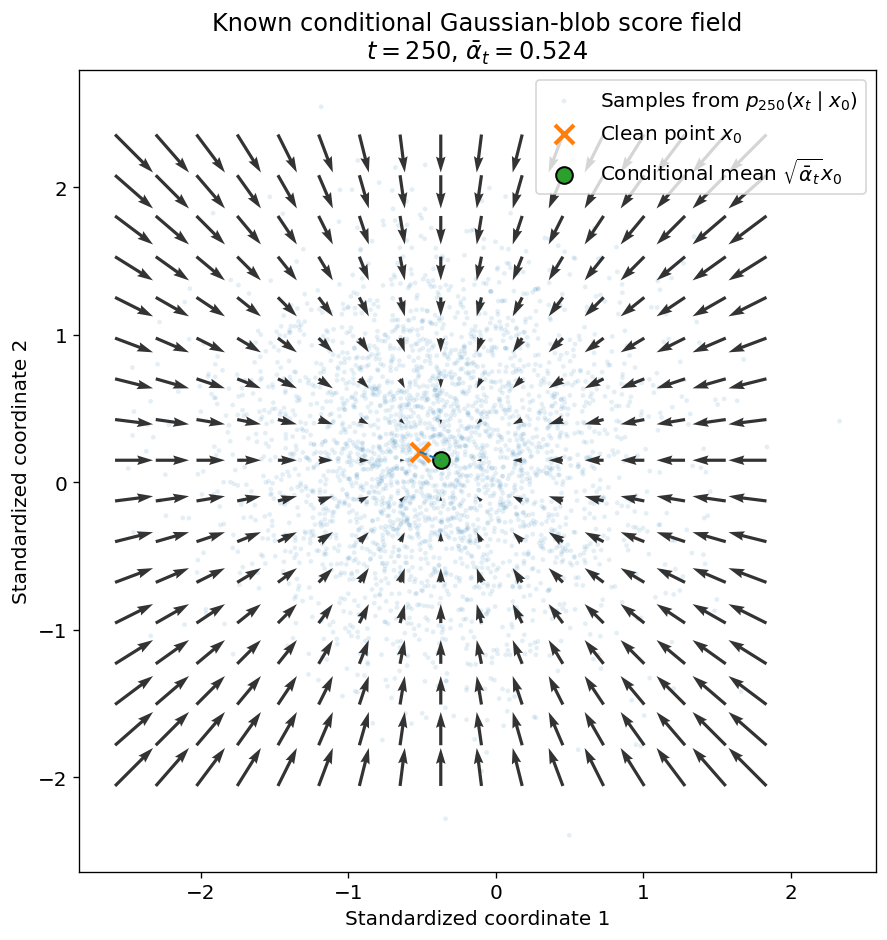

In [18]:
# ── Visualize one conditional Gaussian blob and its exact score field ─────────

# Choose one clean training point and one intermediate noise level.
POINT_INDEX = int(RNG_PLOT.integers(len(data_train)))
T_BLOB = 250

N_BLOB_SAMPLES = 3_000
GRID_SIZE = 17

x0_one = torch.from_numpy(
    data_train[POINT_INDEX:POINT_INDEX + 1]
).to(device=DEVICE, dtype=DTYPE)

t_one = torch.tensor(
    [T_BLOB],
    dtype=torch.long,
    device=DEVICE,
)

sqrt_alpha_bar_one = extract_schedule_value(
    SQRT_ALPHA_BAR,
    t_one,
    x0_one,
)

variance_one = extract_schedule_value(
    ONE_MINUS_ALPHA_BAR,
    t_one,
    x0_one,
)

std_one = torch.sqrt(variance_one)

# The mean of p_t(x_t | x_0).
mu_one = sqrt_alpha_bar_one * x0_one

# Sample points from the conditional Gaussian blob.
x0_repeated = x0_one.repeat(N_BLOB_SAMPLES, 1)
t_repeated = torch.full(
    (N_BLOB_SAMPLES,),
    fill_value=T_BLOB,
    dtype=torch.long,
    device=DEVICE,
)

blob_samples, _ = q_sample(x0_repeated, t_repeated)

# Make a grid around the conditional Gaussian mean.
mu_np = mu_one.detach().cpu().numpy()[0]
std_scalar = std_one.detach().cpu().item()
x0_np = x0_one.detach().cpu().numpy()[0]

grid_half_width = 3.2 * std_scalar

grid_x = np.linspace(
    mu_np[0] - grid_half_width,
    mu_np[0] + grid_half_width,
    GRID_SIZE,
)

grid_y = np.linspace(
    mu_np[1] - grid_half_width,
    mu_np[1] + grid_half_width,
    GRID_SIZE,
)

xx, yy = np.meshgrid(grid_x, grid_y)

grid_points_np = np.column_stack([xx.ravel(), yy.ravel()]).astype(np.float32)

grid_points = torch.from_numpy(grid_points_np).to(
    device=DEVICE,
    dtype=DTYPE,
)

x0_grid = x0_one.repeat(len(grid_points), 1)
t_grid = torch.full(
    (len(grid_points),),
    fill_value=T_BLOB,
    dtype=torch.long,
    device=DEVICE,
)

# Exact conditional Gaussian-blob score at every grid point.
grid_score = conditional_score_target(
    x0=x0_grid,
    xt=grid_points,
    t=t_grid,
).detach().cpu().numpy()

uu = grid_score[:, 0].reshape(xx.shape)
vv = grid_score[:, 1].reshape(yy.shape)

blob_np = blob_samples.detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    blob_np[:, 0],
    blob_np[:, 1],
    s=8,
    alpha=0.12,
    edgecolors="none",
    label=rf"Samples from $p_{{{T_BLOB}}}(x_t \mid x_0)$",
)

ax.quiver(
    xx,
    yy,
    uu,
    vv,
    angles="xy",
    scale_units="xy",
    scale=18,
    width=0.004,
    alpha=0.8,
)

# Clean point before forward noising.
ax.scatter(
    x0_np[0],
    x0_np[1],
    marker="x",
    s=130,
    linewidths=2.5,
    label=r"Clean point $x_0$",
)

# Mean of the conditional Gaussian blob after forward noising.
ax.scatter(
    mu_np[0],
    mu_np[1],
    marker="o",
    s=100,
    edgecolors="black",
    linewidths=1.2,
    label=r"Conditional mean $\sqrt{\bar\alpha_t}x_0$",
)

ax.plot(
    [x0_np[0], mu_np[0]],
    [x0_np[1], mu_np[1]],
    linestyle="--",
    linewidth=1.2,
)

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Standardized coordinate 1")
ax.set_ylabel("Standardized coordinate 2")

ax.set_title(
    "Known conditional Gaussian-blob score field\n"
    + rf"$t={T_BLOB}$, "
    + rf"$\bar{{\alpha}}_t={ALPHA_BAR[T_BLOB].item():.3f}$"
)

ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.savefig(
    FIG_DIR / "05_conditional_gaussian_blob_score_target.png",
    bbox_inches="tight",
)
plt.show()

# 7. Define the variance-weighted score-matching loss

For every noisy point in a mini-batch, the neural network predicts a score vector:

$$
\hat a^{(b)}
=
s_\theta
\left(
x_{t^{(b)}}^{(b)},
t^{(b)}
\right)
$$

The known conditional Gaussian-blob score from Section 6 is:

$$
a^{(b)}
=
\nabla_{x_{t^{(b)}}^{(b)}}
\log
p_{t^{(b)}}
\left(
x_{t^{(b)}}^{(b)}
\mid
x_0^{(b)}
\right)
$$

A direct squared error would be:

$$
\left\|
\hat a^{(b)}-a^{(b)}
\right\|^2
$$

However, at very small noise levels, the conditional score target can become very large:

$$
a^{(b)}
=
-\frac{
\epsilon^{(b)}
}{
\sqrt{1-\bar\alpha_{t^{(b)}}}
}
$$

We therefore weight the squared error by the conditional variance:

$$
\ell^{(b)}(\theta)
=
\left(
1-\bar\alpha_{t^{(b)}}
\right)
\left\|
\hat a^{(b)}-a^{(b)}
\right\|^2
$$

The final mini-batch loss is:

$$
\mathcal L_{\mathrm{batch}}(\theta)
=
\frac{1}{B}
\sum_{b=1}^{B}
\ell^{(b)}(\theta)
$$

The neural network still predicts the score directly.

The variance factor only prevents the very-low-noise score targets from dominating the training objective.

In [21]:
# ── 7. Define the variance-weighted score-matching loss ──────────────────────

def variance_weighted_score_matching_loss(
    predicted_score: torch.Tensor,
    target_score: torch.Tensor,
    t: torch.Tensor,
):
    """
    Calculate the variance-weighted score-matching loss.

    For each batch example b:

        ell^(b)
        =
        (1 - alpha_bar_t)
        * || predicted_score^(b) - target_score^(b) ||^2

    The batch loss is the mean over all examples.

    Parameters
    ----------
    predicted_score : torch.Tensor, shape (B, 2)
        Score vectors predicted by the neural network.

    target_score : torch.Tensor, shape (B, 2)
        Known conditional Gaussian-blob score targets.

    t : torch.Tensor, shape (B,)
        Noise level for every batch example.

    Returns
    -------
    batch_loss : torch.Tensor, scalar
        Mean variance-weighted score-matching loss.

    per_example_loss : torch.Tensor, shape (B,)
        One weighted loss value for each batch example.

    squared_error : torch.Tensor, shape (B,)
        Unweighted squared score error for each batch example.

    variance_t : torch.Tensor, shape (B,)
        Conditional variance 1 - alpha_bar_t for each batch example.
    """
    if predicted_score.shape != target_score.shape:
        raise ValueError(
            "predicted_score and target_score must have the same shape. "
            f"Received {tuple(predicted_score.shape)} and "
            f"{tuple(target_score.shape)}."
        )

    if predicted_score.ndim != 2 or predicted_score.shape[1] != 2:
        raise ValueError(
            "predicted_score and target_score must each have shape (B, 2)."
        )

    if t.ndim != 1 or t.shape[0] != predicted_score.shape[0]:
        raise ValueError(
            "t must have shape (B,), with the same batch size as the score tensors."
        )

    t = t.to(device=predicted_score.device, dtype=torch.long)

    if torch.any(t < 1) or torch.any(t > T):
        raise ValueError(
            f"All time indices must lie in {{1, ..., {T}}}."
        )

    # Shape before squeeze: (B, 1)
    variance_t = extract_schedule_value(
        ONE_MINUS_ALPHA_BAR,
        t,
        predicted_score,
    )

    # || predicted_score - target_score ||^2 for every batch example.
    squared_error = (predicted_score - target_score).pow(2).sum(dim=1)

    # Shape: (B,)
    variance_t = variance_t.squeeze(dim=1)

    # Shape: (B,)
    per_example_loss = variance_t * squared_error

    # Scalar.
    batch_loss = per_example_loss.mean()

    return batch_loss, per_example_loss, squared_error, variance_t


def score_matching_loss(
    model: nn.Module,
    x0: torch.Tensor,
    return_details: bool = False,
):
    """
    Create one noisy mini-batch, predict scores, and calculate the
    variance-weighted score-matching loss.

    Parameters
    ----------
    model : nn.Module
        Neural network representing s_theta(x_t, t).

    x0 : torch.Tensor, shape (B, 2)
        Batch of clean data points.

    return_details : bool
        Whether to return intermediate tensors for diagnostics.

    Returns
    -------
    batch_loss : torch.Tensor, scalar

    details : dict, optional
        Intermediate quantities used to calculate the loss.
    """
    if x0.ndim != 2 or x0.shape[1] != 2:
        raise ValueError(
            "x0 must have shape (B, 2), "
            f"but received {tuple(x0.shape)}."
        )

    # Section 6:
    # sample one time and one Gaussian noise vector for each clean point,
    # then create x_t and its known conditional score target.
    xt, t, eps, target_score = prepare_score_training_batch(x0)

    # Section 5:
    # predict one score vector for each noisy point.
    predicted_score = model(xt, t)

    batch_loss, per_example_loss, squared_error, variance_t = (
        variance_weighted_score_matching_loss(
            predicted_score=predicted_score,
            target_score=target_score,
            t=t,
        )
    )

    if not return_details:
        return batch_loss

    details = {
        "x0": x0,
        "xt": xt,
        "t": t,
        "eps": eps,
        "target_score": target_score,
        "predicted_score": predicted_score,
        "squared_error": squared_error,
        "variance_t": variance_t,
        "per_example_loss": per_example_loss,
    }

    return batch_loss, details

## Visualize why the variance weighting is useful

At low noise levels:

$$
1-\bar\alpha_t
$$

is small.

Therefore, the conditional score target has a large typical magnitude:

$$
\left\|
a
\right\|
\propto
\frac{1}{
\sqrt{1-\bar\alpha_t}
}
$$

The variance weight:

$$
1-\bar\alpha_t
$$

reduces the influence of these very-large low-noise targets.

This lets the model learn score fields across the whole range of noise levels.

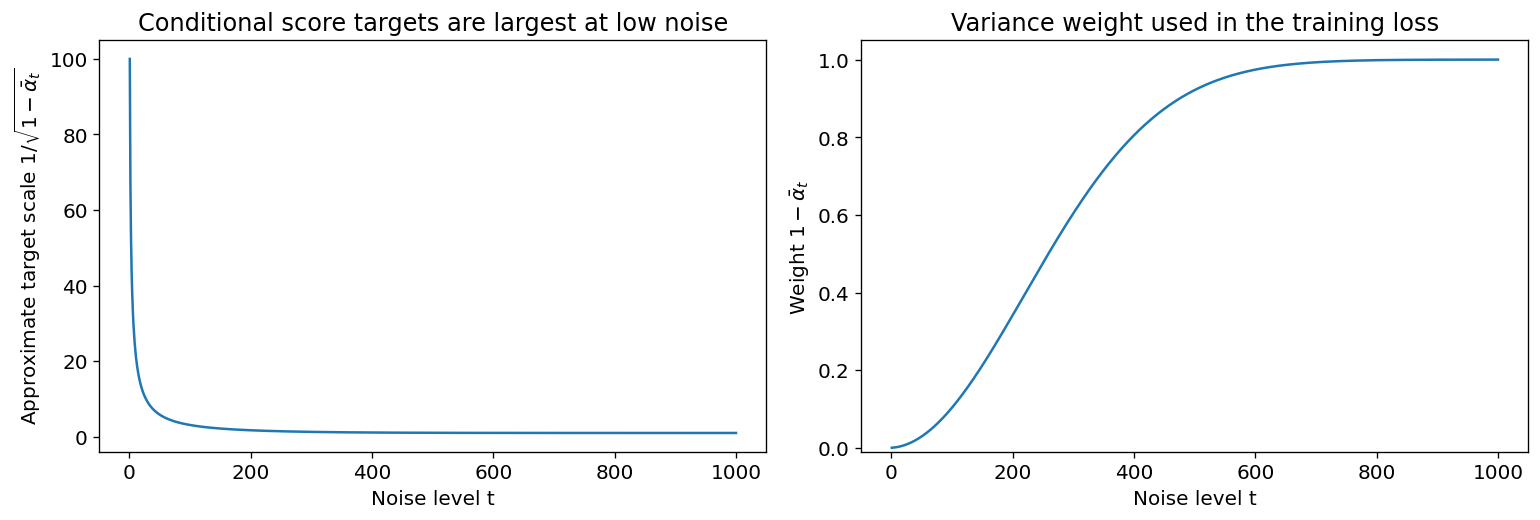

In [22]:
# ── Visualize the effect of variance weighting ────────────────────────────────

t_axis = np.arange(1, T + 1)

variance_np = ONE_MINUS_ALPHA_BAR[1:].detach().cpu().numpy()

# Typical scale of the conditional score target:
#
# a = -epsilon / sqrt(1 - alpha_bar_t)
#
# Since epsilon has roughly unit scale, this curve shows the approximate
# magnitude introduced by the denominator.
target_scale_np = 1.0 / np.sqrt(variance_np)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(t_axis, target_scale_np)
axes[0].set_xlabel("Noise level t")
axes[0].set_ylabel(
    r"Approximate target scale "
    r"$1 / \sqrt{1-\bar{\alpha}_t}$"
)
axes[0].set_title("Conditional score targets are largest at low noise")

axes[1].plot(t_axis, variance_np)
axes[1].set_xlabel("Noise level t")
axes[1].set_ylabel(r"Weight $1-\bar{\alpha}_t$")
axes[1].set_ylim(bottom=-0.01)
axes[1].set_title("Variance weight used in the training loss")

plt.tight_layout()
plt.savefig(FIG_DIR / "06_variance_weighted_score_loss.png", bbox_inches="tight")
plt.show()

## Sanity-check the loss on one mini-batch

For an untrained neural network, the predicted score arrows are random.

Therefore, the loss will usually be relatively large.

At this stage, we only check that:

- the loss is a finite scalar;
- the model returns one prediction per noisy point;
- gradients can flow from the loss back to the MLP parameters.

In [23]:
# ── Sanity-check the score-matching loss ──────────────────────────────────────

x0_batch = next(iter(train_loader))[0].to(device=DEVICE, dtype=DTYPE)

score_model.train()

batch_loss, loss_details = score_matching_loss(
    model=score_model,
    x0=x0_batch,
    return_details=True,
)

print(f"Batch loss                  : {batch_loss.item():.6f}")
print(f"Mean unweighted score error : {loss_details['squared_error'].mean().item():.6f}")
print(f"Mean variance weight        : {loss_details['variance_t'].mean().item():.6f}")
print(f"Mean weighted example loss  : {loss_details['per_example_loss'].mean().item():.6f}")

if not torch.isfinite(batch_loss):
    raise RuntimeError("The batch loss is not finite.")

if loss_details["predicted_score"].shape != x0_batch.shape:
    raise RuntimeError(
        "The score model must return one 2D prediction for every clean point."
    )

# Check that gradients can flow through the network.
score_model.zero_grad(set_to_none=True)
batch_loss.backward()

parameters_with_gradients = [
    parameter
    for parameter in score_model.parameters()
    if parameter.grad is not None
]

if len(parameters_with_gradients) == 0:
    raise RuntimeError("No gradients reached the score-model parameters.")

gradient_norm_squared = sum(
    parameter.grad.detach().pow(2).sum().item()
    for parameter in parameters_with_gradients
)

gradient_norm = np.sqrt(gradient_norm_squared)

print(f"Gradient norm                : {gradient_norm:.6f}")

# Clear the diagnostic gradients.
score_model.zero_grad(set_to_none=True)

Batch loss                  : 2.001076
Mean unweighted score error : 41.059036
Mean variance weight        : 0.743581
Mean weighted example loss  : 2.001076
Gradient norm                : 0.563396


# 8. Train the score model

We now repeat the training procedure over many mini-batches.

For each mini-batch:

1. Draw clean points:

$$
\left\{
x_0^{(b)}
\right\}_{b=1}^{B}
$$

2. Independently sample a noise level and Gaussian noise for every point:

$$
t^{(b)}
\sim
\mathrm{Uniform}\{1,\ldots,T\}
$$

$$
\epsilon^{(b)}
\sim
\mathcal N(0,I)
$$

3. Construct noisy points and known conditional score targets:

$$
x_{t^{(b)}}^{(b)}
=
\sqrt{\bar\alpha_{t^{(b)}}}\,x_0^{(b)}
+
\sqrt{1-\bar\alpha_{t^{(b)}}}\,\epsilon^{(b)}
$$

$$
a^{(b)}
=
-\frac{
\epsilon^{(b)}
}{
\sqrt{
1-\bar\alpha_{t^{(b)}}
}
}
$$

4. Ask the MLP to predict the score:

$$
\hat a^{(b)}
=
s_\theta
\left(
x_{t^{(b)}}^{(b)},
t^{(b)}
\right)
$$

5. Calculate the variance-weighted score-matching loss:

$$
\mathcal L_{\mathrm{batch}}(\theta)
=
\frac{1}{B}
\sum_{b=1}^{B}
\left(
1-\bar\alpha_{t^{(b)}}
\right)
\left\|
\hat a^{(b)}-a^{(b)}
\right\|^2
$$

6. Backpropagate the loss and update the network parameters:

$$
\theta
\leftarrow
\theta
-
\eta
\nabla_\theta
\mathcal L_{\mathrm{batch}}(\theta)
$$

The same procedure is used for validation, except that validation does not calculate gradients and does not update the model.

In [24]:
# ── 8. Training configuration and helper functions ────────────────────────────

LEARNING_RATE = 1e-3
N_EPOCHS = 300
PRINT_EVERY = 25

BEST_CHECKPOINT_PATH = CKPT_DIR / "score_mlp_best.pt"

optimizer = torch.optim.Adam(
    score_model.parameters(),
    lr=LEARNING_RATE,
)


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
) -> float:
    """
    Train the score model for one full pass through the training DataLoader.

    Returns
    -------
    mean_epoch_loss : float
        Mean variance-weighted score-matching loss over all training examples.
    """
    model.train()

    total_loss = 0.0
    total_examples = 0

    for (x0_batch,) in loader:
        x0_batch = x0_batch.to(device=DEVICE, dtype=DTYPE)

        # 1–3. Sample t and epsilon, then create x_t and target scores.
        # 4. Predict scores.
        # 5. Calculate the weighted batch loss.
        batch_loss = score_matching_loss(
            model=model,
            x0=x0_batch,
        )

        # 6. Backpropagate and update theta.
        optimizer.zero_grad(set_to_none=True)
        batch_loss.backward()
        optimizer.step()

        batch_size = x0_batch.shape[0]

        # batch_loss is already averaged within its mini-batch.
        # Multiplying by batch_size lets us calculate an example-weighted
        # average over the full epoch.
        total_loss += batch_loss.detach().item() * batch_size
        total_examples += batch_size

    if total_examples == 0:
        raise RuntimeError("The training DataLoader returned no examples.")

    return total_loss / total_examples


@torch.no_grad()
def validate(
    model: nn.Module,
    loader: DataLoader,
) -> float:
    """
    Evaluate the score model on held-out clean points.

    Fresh random times and fresh Gaussian noise are sampled for validation.
    The network is not updated.
    """
    model.eval()

    total_loss = 0.0
    total_examples = 0

    for (x0_batch,) in loader:
        x0_batch = x0_batch.to(device=DEVICE, dtype=DTYPE)

        batch_loss = score_matching_loss(
            model=model,
            x0=x0_batch,
        )

        batch_size = x0_batch.shape[0]

        total_loss += batch_loss.item() * batch_size
        total_examples += batch_size

    if total_examples == 0:
        raise RuntimeError("The validation DataLoader returned no examples.")

    return total_loss / total_examples


def save_checkpoint(
    path: Path,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    train_loss: float,
    valid_loss: float,
) -> None:
    """
    Save everything needed to reload the trained score model later.
    """
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": train_loss,
        "valid_loss": valid_loss,
        "model_config": {
            "hidden_dim": HIDDEN_DIM,
            "n_hidden_layers": N_HIDDEN_LAYERS,
            "num_timesteps": T,
        },
        "diffusion_config": {
            "T": T,
            "beta_min": BETA_MIN,
            "beta_max": BETA_MAX,
            "beta_schedule": BETA.detach().cpu(),
        },
        "data_standardization": {
            "mean": DATA_MEAN,
            "std": DATA_STD,
        },
    }

    torch.save(checkpoint, path)

## Train the model

At every epoch, the model sees every clean training point once.

However, the noisy version of each point is different each time because we resample:

$$
t^{(b)}
$$

and:

$$
\epsilon^{(b)}
$$

every time that point appears in a mini-batch.

Therefore, the model gradually learns score arrows across many locations and across the full range of noise levels.

In [25]:
# ── Train the score model ─────────────────────────────────────────────────────

history = {
    "epoch": [],
    "train_loss": [],
    "valid_loss": [],
}

best_valid_loss = float("inf")
best_epoch = None

print("Starting training...\n")

for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_one_epoch(
        model=score_model,
        loader=train_loader,
        optimizer=optimizer,
    )

    valid_loss = validate(
        model=score_model,
        loader=valid_loader,
    )

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)

    # Save the model whenever it achieves the best validation loss so far.
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_epoch = epoch

        save_checkpoint(
            path=BEST_CHECKPOINT_PATH,
            model=score_model,
            optimizer=optimizer,
            epoch=epoch,
            train_loss=train_loss,
            valid_loss=valid_loss,
        )

    should_print = (
        epoch == 1
        or epoch % PRINT_EVERY == 0
        or epoch == N_EPOCHS
    )

    if should_print:
        marker = "  ← best model" if epoch == best_epoch else ""

        print(
            f"Epoch {epoch:>3}/{N_EPOCHS} | "
            f"train loss: {train_loss:.6f} | "
            f"valid loss: {valid_loss:.6f}"
            f"{marker}"
        )

print("\nTraining complete.")
print(f"Best validation loss: {best_valid_loss:.6f}")
print(f"Best epoch          : {best_epoch}")
print(f"Saved checkpoint    : {BEST_CHECKPOINT_PATH.resolve()}")

Starting training...

Epoch   1/300 | train loss: 0.931026 | valid loss: 0.582030  ← best model
Epoch  25/300 | train loss: 0.454743 | valid loss: 0.430583  ← best model
Epoch  50/300 | train loss: 0.426628 | valid loss: 0.402696
Epoch  75/300 | train loss: 0.444020 | valid loss: 0.395132
Epoch 100/300 | train loss: 0.409980 | valid loss: 0.427232
Epoch 125/300 | train loss: 0.414629 | valid loss: 0.402860
Epoch 150/300 | train loss: 0.403081 | valid loss: 0.371067
Epoch 175/300 | train loss: 0.396854 | valid loss: 0.395979
Epoch 200/300 | train loss: 0.386815 | valid loss: 0.381177
Epoch 225/300 | train loss: 0.390663 | valid loss: 0.411681
Epoch 250/300 | train loss: 0.410627 | valid loss: 0.397494
Epoch 275/300 | train loss: 0.381135 | valid loss: 0.408797
Epoch 300/300 | train loss: 0.400128 | valid loss: 0.386442

Training complete.
Best validation loss: 0.323726
Best epoch          : 248
Saved checkpoint    : /Users/tiam/github/tiamheydari.github.io/_teaching/Modern_AI/notebooks/

## Load the best validation checkpoint

The final epoch is not necessarily the best model.

We therefore reload the checkpoint with the smallest validation loss before moving to the score-field diagnostics.

In [26]:
# ── Reload the best validation model ──────────────────────────────────────────

if not BEST_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Could not find the saved best-model checkpoint: {BEST_CHECKPOINT_PATH}"
    )

best_checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=DEVICE,
)

score_model.load_state_dict(best_checkpoint["model_state_dict"])
score_model.eval()

print(f"Reloaded checkpoint from epoch {best_checkpoint['epoch']}")
print(f"Training loss at checkpoint   : {best_checkpoint['train_loss']:.6f}")
print(f"Validation loss at checkpoint : {best_checkpoint['valid_loss']:.6f}")

Reloaded checkpoint from epoch 248
Training loss at checkpoint   : 0.395615
Validation loss at checkpoint : 0.323726


## Visualize training progress

The training and validation losses should decrease overall.


They will not be perfectly smooth because every epoch uses newly sampled noise levels and Gaussian noise.

The important pattern is that the validation loss should broadly follow the training loss rather than rising strongly while the training loss continues to fall.

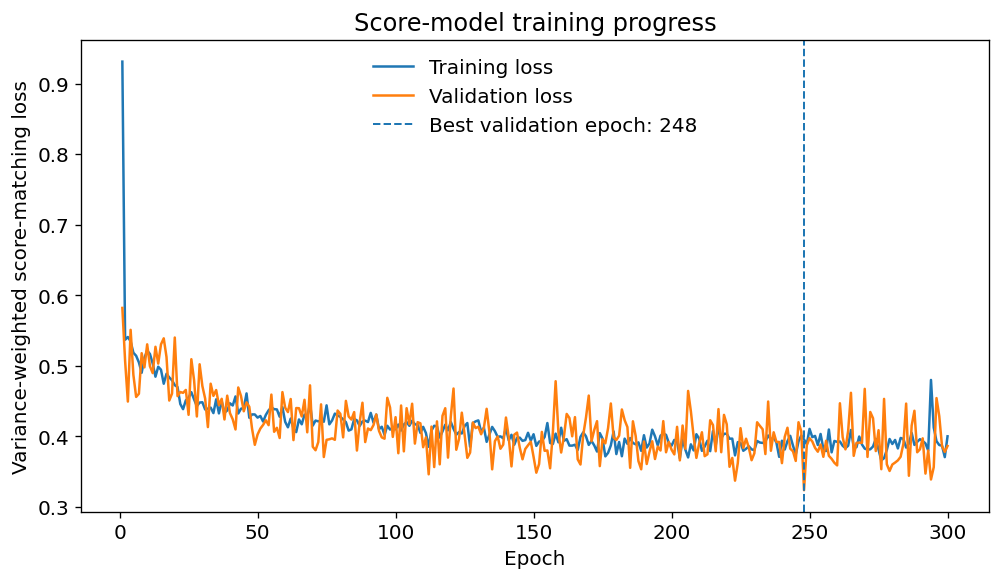

In [27]:
# ── Plot training and validation losses ───────────────────────────────────────

epochs = np.asarray(history["epoch"])
train_losses = np.asarray(history["train_loss"])
valid_losses = np.asarray(history["valid_loss"])

fig, ax = plt.subplots(figsize=(8.5, 5))

ax.plot(
    epochs,
    train_losses,
    label="Training loss",
)

ax.plot(
    epochs,
    valid_losses,
    label="Validation loss",
)

ax.axvline(
    best_epoch,
    linestyle="--",
    linewidth=1.2,
    label=f"Best validation epoch: {best_epoch}",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Variance-weighted score-matching loss")
ax.set_title("Score-model training progress")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(FIG_DIR / "07_training_validation_loss.png", bbox_inches="tight")
plt.show()

# 9 Diagnostics after training
### below is ony for visualizing the snapshots of Score, you can skip

Training device: mps
Number of epochs: 300
Learning rate: 0.001
Snapshot epochs: [5, 25, 100, 200, 300]

Starting training...

Epoch   1/300 | train loss: 0.929162 | valid loss: 0.571535  ← current best
Epoch  25/300 | train loss: 0.444059 | valid loss: 0.472604
Epoch  50/300 | train loss: 0.438933 | valid loss: 0.464893
Epoch  75/300 | train loss: 0.415512 | valid loss: 0.419847
Epoch 100/300 | train loss: 0.407109 | valid loss: 0.441584
Epoch 125/300 | train loss: 0.401372 | valid loss: 0.389574
Epoch 150/300 | train loss: 0.397563 | valid loss: 0.390066
Epoch 175/300 | train loss: 0.397815 | valid loss: 0.465885
Epoch 200/300 | train loss: 0.408486 | valid loss: 0.433115
Epoch 225/300 | train loss: 0.372096 | valid loss: 0.387634
Epoch 250/300 | train loss: 0.377083 | valid loss: 0.406724
Epoch 275/300 | train loss: 0.390429 | valid loss: 0.392933
Epoch 300/300 | train loss: 0.377254 | valid loss: 0.438369

Training complete.
Best validation loss: 0.329041
Best epoch          : 159


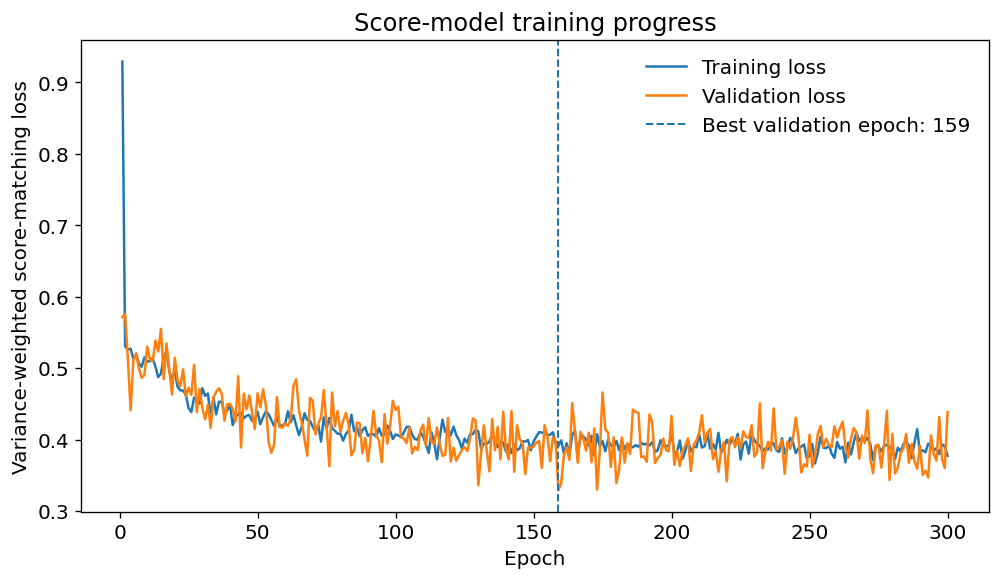

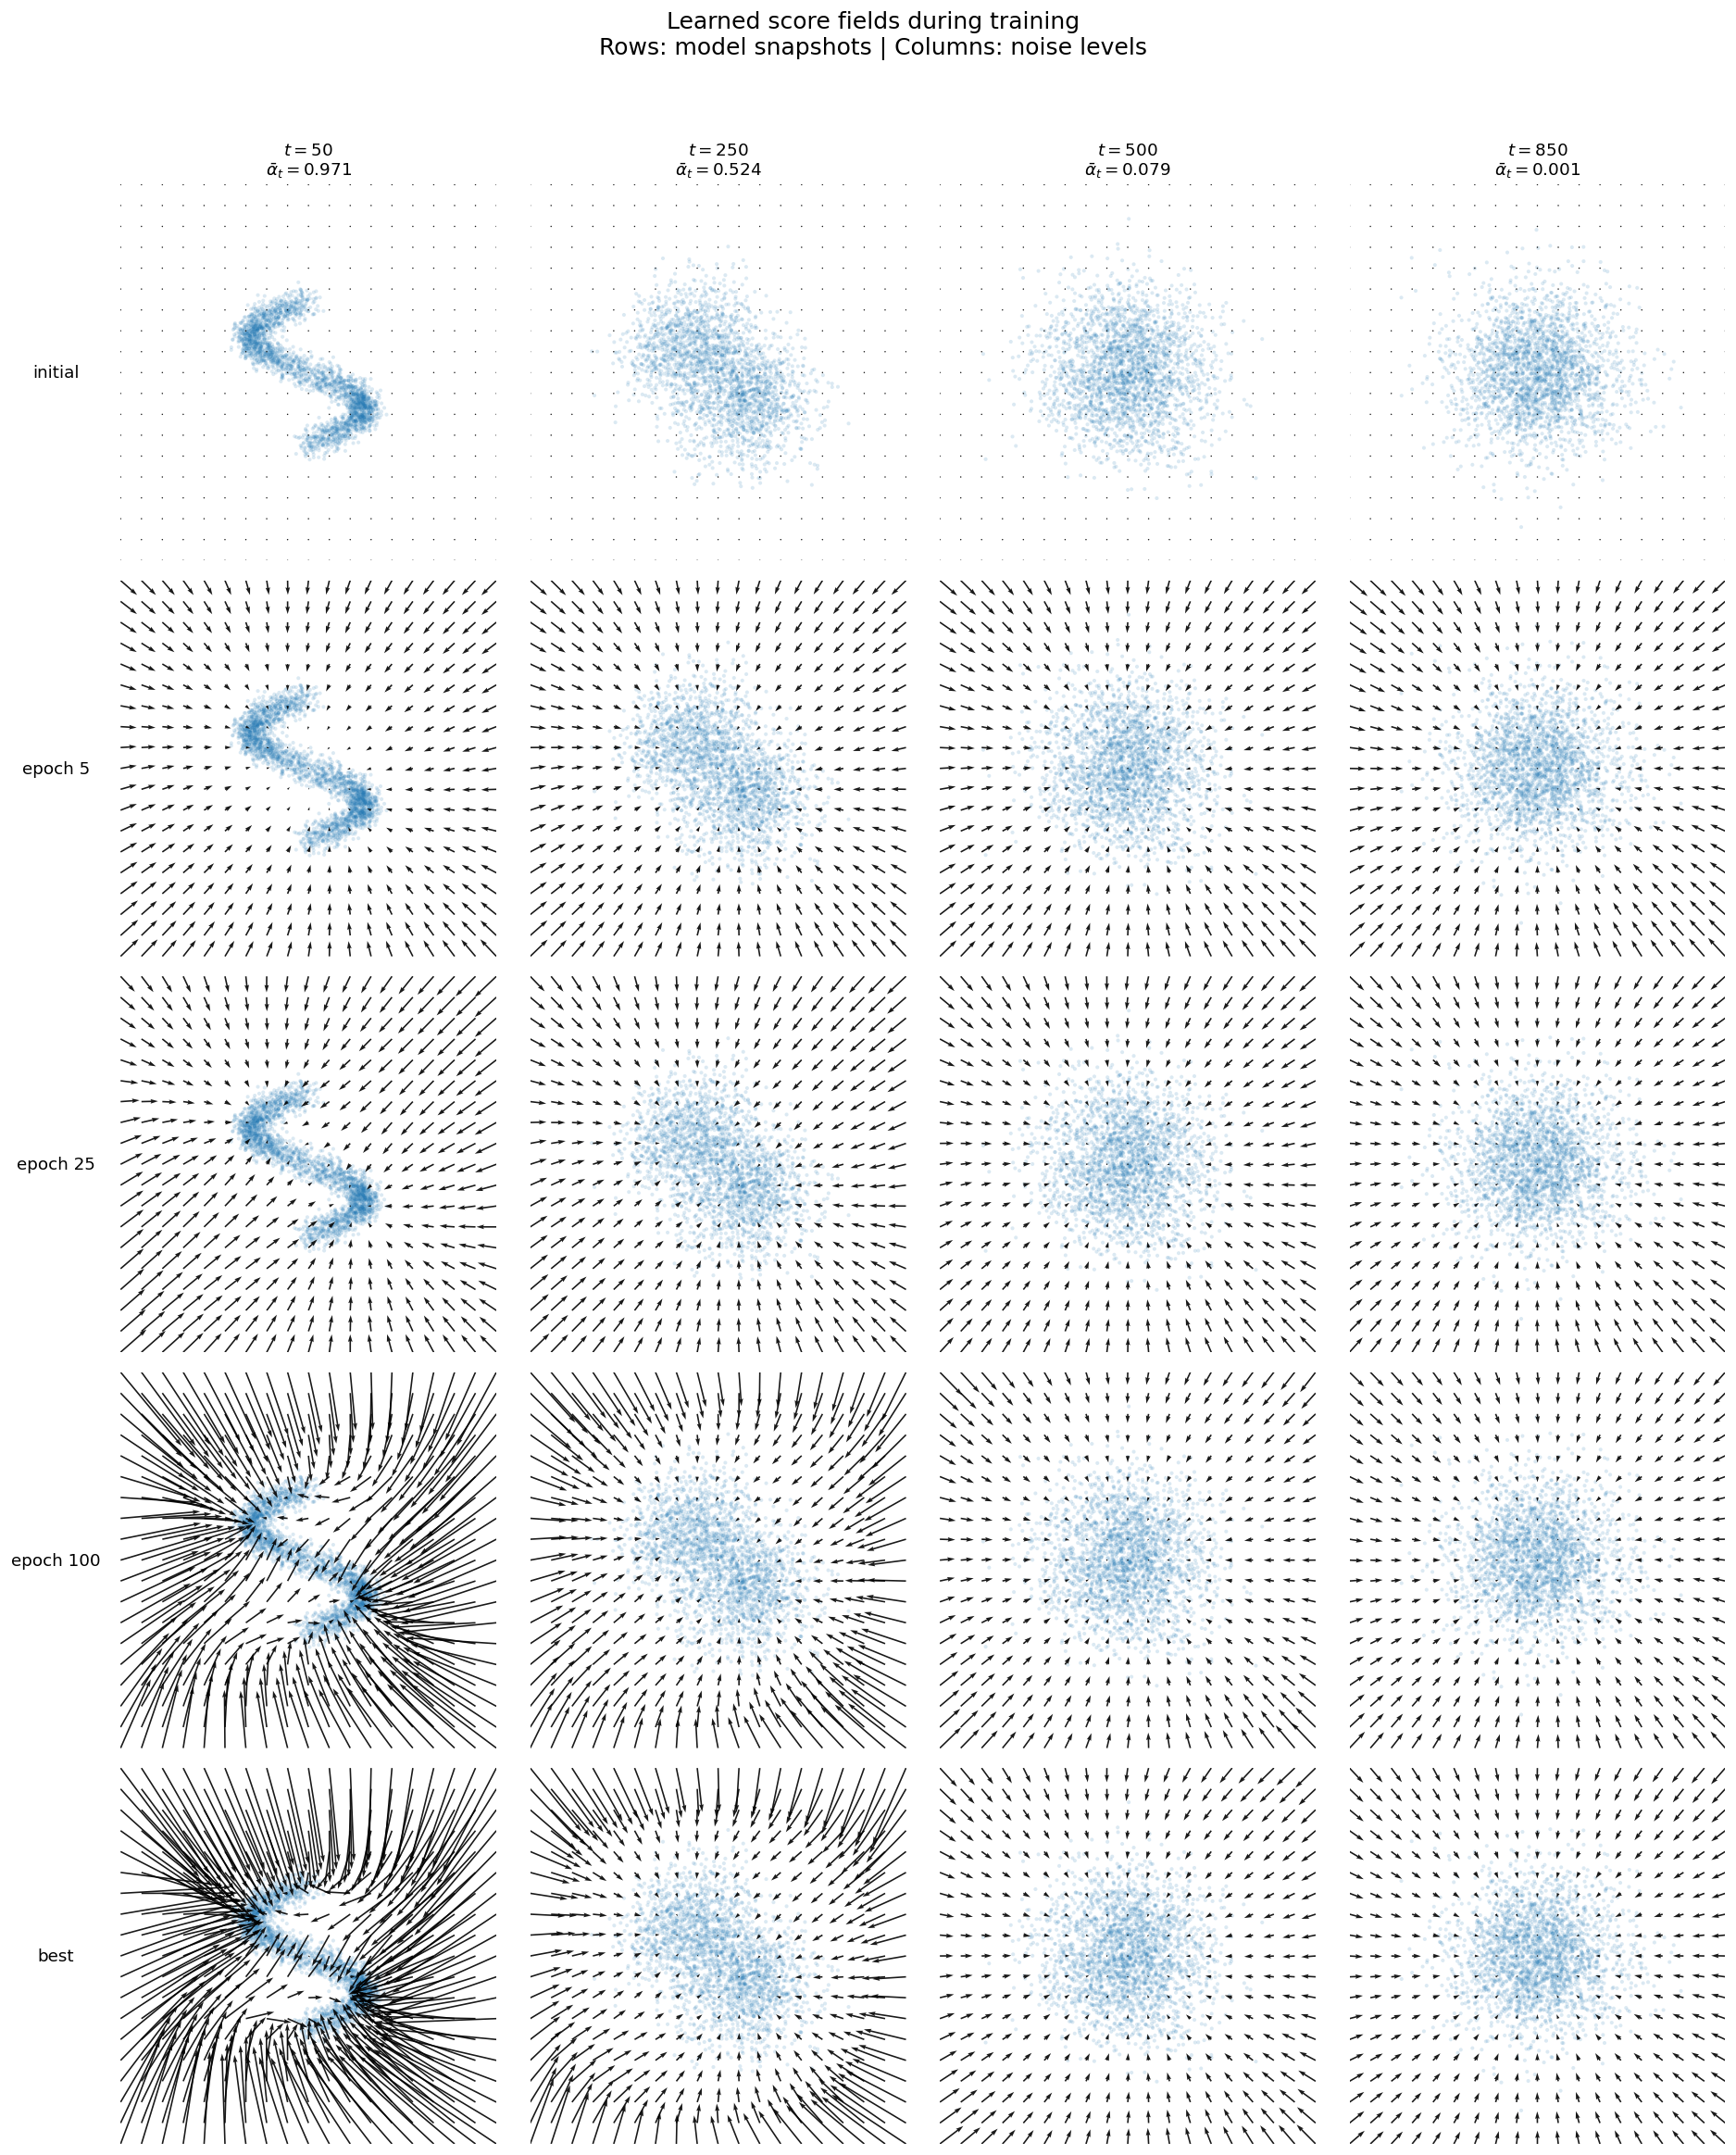

Saved score-field comparison to:
/Users/tiam/github/tiamheydari.github.io/_teaching/Modern_AI/notebooks/Workshop_E.4_diffusion_II/figures_diffusion_mlp/08_learned_score_fields_during_training.png


In [ ]:
### only if we want snapshots during training, otherwise we can skip this section and the next one
# ── 8. Train the score model and save score-field snapshots ──────────────────

# =============================================================================
# 8.1 Training configuration
# =============================================================================

LEARNING_RATE = 1e-3
N_EPOCHS = 300
PRINT_EVERY = 25

BEST_CHECKPOINT_PATH = CKPT_DIR / "score_mlp_best.pt"

# Save these intermediate model states during training.
# "initial" is always saved automatically before Epoch 1.
#
# Change this list to choose the intermediate stages you want to compare.
SNAPSHOT_EPOCHS = [5, 25, 100, 200, 300]

# Choose which saved model snapshots to visualize after training.
#
# Valid names will be printed after training. The defaults below correspond to
# the snapshot epochs above.
PLOT_SNAPSHOT_NAMES = [
    "initial",
    "epoch_5",
    "epoch_25",
    "epoch_100",
    "best",
]

# Choose the diffusion noise levels at which to visualize the learned field.
#
# Do not include t = 0: the score model was trained only at t = 1, ..., T.
PLOT_FIELD_TIMES = [50, 250, 500, 850]

# Visualization settings. Adjust these without retraining.
N_FIELD_CLOUD = 2_500
FIELD_GRID_SIZE = 19
FIELD_LIMIT = 4.5
SCORE_QUIVER_SCALE = 14.0
FIELD_SEED = SEED + 500


# =============================================================================
# 8.2 Reinitialize the model and optimizer
# =============================================================================
#
# This ensures that "initial" is always an untrained model, even if you rerun
# this section after a previous experiment.

torch.manual_seed(SEED + 10)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED + 10)

score_model = ScoreMLP(
    hidden_dim=HIDDEN_DIM,
    n_hidden_layers=N_HIDDEN_LAYERS,
    num_timesteps=T,
).to(device=DEVICE, dtype=DTYPE)

optimizer = torch.optim.Adam(
    score_model.parameters(),
    lr=LEARNING_RATE,
)

print(f"Training device: {DEVICE}")
print(f"Number of epochs: {N_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Snapshot epochs: {SNAPSHOT_EPOCHS}")


# =============================================================================
# 8.3 Helper functions for training, validation, and snapshots
# =============================================================================

def model_state_to_cpu(model: nn.Module) -> dict:
    """
    Copy a model state dictionary to CPU memory.

    Keeping snapshots on CPU avoids filling GPU or MPS memory while training.
    """
    return {
        name: tensor.detach().cpu().clone()
        for name, tensor in model.state_dict().items()
    }


def build_model_from_state_dict(state_dict: dict) -> nn.Module:
    """
    Build a fresh score model and load a saved snapshot into it.
    """
    model = ScoreMLP(
        hidden_dim=HIDDEN_DIM,
        n_hidden_layers=N_HIDDEN_LAYERS,
        num_timesteps=T,
    ).to(device=DEVICE, dtype=DTYPE)

    model.load_state_dict(state_dict)
    model.eval()

    return model


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
) -> float:
    """
    Train for one full pass through the training DataLoader.
    """
    model.train()

    total_loss = 0.0
    total_examples = 0

    for (x0_batch,) in loader:
        x0_batch = x0_batch.to(device=DEVICE, dtype=DTYPE)

        # Sections 6 and 7:
        # Create noisy points, calculate score targets, predict scores,
        # and calculate the variance-weighted score-matching loss.
        batch_loss = score_matching_loss(
            model=model,
            x0=x0_batch,
        )

        # Backpropagate and update theta.
        optimizer.zero_grad(set_to_none=True)
        batch_loss.backward()
        optimizer.step()

        batch_size = x0_batch.shape[0]

        total_loss += batch_loss.detach().item() * batch_size
        total_examples += batch_size

    if total_examples == 0:
        raise RuntimeError("The training DataLoader returned no examples.")

    return total_loss / total_examples


@torch.no_grad()
def validate(
    model: nn.Module,
    loader: DataLoader,
) -> float:
    """
    Calculate the validation score-matching loss.

    Validation samples fresh times and fresh Gaussian noise, but does not
    calculate gradients or update the model.
    """
    model.eval()

    total_loss = 0.0
    total_examples = 0

    for (x0_batch,) in loader:
        x0_batch = x0_batch.to(device=DEVICE, dtype=DTYPE)

        batch_loss = score_matching_loss(
            model=model,
            x0=x0_batch,
        )

        batch_size = x0_batch.shape[0]

        total_loss += batch_loss.item() * batch_size
        total_examples += batch_size

    if total_examples == 0:
        raise RuntimeError("The validation DataLoader returned no examples.")

    return total_loss / total_examples


def save_checkpoint(
    path: Path,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    train_loss: float,
    valid_loss: float,
) -> None:
    """
    Save the best model and everything needed to use it later.
    """
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model_state_to_cpu(model),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": train_loss,
        "valid_loss": valid_loss,
        "model_config": {
            "hidden_dim": HIDDEN_DIM,
            "n_hidden_layers": N_HIDDEN_LAYERS,
            "num_timesteps": T,
        },
        "diffusion_config": {
            "T": T,
            "beta_min": BETA_MIN,
            "beta_max": BETA_MAX,
            "beta_schedule": BETA.detach().cpu(),
        },
        "data_standardization": {
            "mean": DATA_MEAN,
            "std": DATA_STD,
        },
    }

    torch.save(checkpoint, path)


# =============================================================================
# 8.4 Fixed reference data for score-field visualizations
# =============================================================================
#
# The same noisy cloud is used for all model snapshots at a given time t.
# Therefore, differences between rows reflect learning, not different noise.

if N_FIELD_CLOUD > len(data_train):
    raise ValueError(
        "N_FIELD_CLOUD cannot be larger than the number of training examples."
    )

rng_field = np.random.default_rng(FIELD_SEED)

field_indices = rng_field.choice(
    len(data_train),
    size=N_FIELD_CLOUD,
    replace=False,
)

field_x0 = data_train[field_indices].astype(np.float32)


def make_fixed_noisy_cloud(t_value: int) -> np.ndarray:
    """
    Create a deterministic noisy S-shaped cloud for visualization at one time.

    The cloud is fixed for each t_value, so every model snapshot is compared
    on exactly the same noisy examples.
    """
    if not isinstance(t_value, (int, np.integer)):
        raise TypeError("t_value must be an integer.")

    if t_value < 1 or t_value > T:
        raise ValueError(f"t_value must lie in {{1, ..., {T}}}.")

    local_rng = np.random.default_rng(FIELD_SEED + int(t_value))

    eps = local_rng.standard_normal(field_x0.shape).astype(np.float32)

    alpha_bar_value = ALPHA_BAR[t_value].detach().cpu().item()

    return (
        np.sqrt(alpha_bar_value) * field_x0
        + np.sqrt(1.0 - alpha_bar_value) * eps
    ).astype(np.float32)


def predict_score_on_grid(
    model: nn.Module,
    t_value: int,
    xx: np.ndarray,
    yy: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Predict the learned score vector on every point of a 2D grid.
    """
    grid_points_np = np.column_stack(
        [
            xx.ravel(),
            yy.ravel(),
        ]
    ).astype(np.float32)

    grid_points = torch.from_numpy(grid_points_np).to(
        device=DEVICE,
        dtype=DTYPE,
    )

    t_grid = torch.full(
        (len(grid_points),),
        fill_value=t_value,
        dtype=torch.long,
        device=DEVICE,
    )

    with torch.no_grad():
        score_grid = model(grid_points, t_grid)

    score_grid = score_grid.detach().cpu().numpy()

    u = score_grid[:, 0].reshape(xx.shape)
    v = score_grid[:, 1].reshape(yy.shape)

    return u, v

def plot_score_field_snapshots(
    snapshot_store: dict,
    snapshot_names: list[str],
    time_values: list[int],
    field_limit: float = FIELD_LIMIT,
    grid_size: int = FIELD_GRID_SIZE,
    quiver_scale: float = SCORE_QUIVER_SCALE,
    arrow_color: str = "#632C8A",
    save_name: str = "08_learned_score_fields_during_training.png",
):
    """
    Plot learned score fields.

    Rows correspond to model snapshots, such as:
        initial, epoch_25, epoch_100, best

    Columns correspond to diffusion noise levels t.

    The noisy cloud at each t is identical across all rows.

    Parameters
    ----------
    arrow_color : str
        Color used for score-field arrows.
        Default: "#632C8A".
    """
    if len(snapshot_names) == 0:
        raise ValueError("snapshot_names cannot be empty.")

    if len(time_values) == 0:
        raise ValueError("time_values cannot be empty.")

    missing_snapshots = [
        name for name in snapshot_names
        if name not in snapshot_store
    ]

    if missing_snapshots:
        available = ", ".join(snapshot_store.keys())
        raise KeyError(
            f"Unknown snapshots: {missing_snapshots}. "
            f"Available snapshots are: {available}"
        )

    for t_value in time_values:
        if t_value < 1 or t_value > T:
            raise ValueError(
                f"All time values must lie in {{1, ..., {T}}}."
            )

    grid_axis = np.linspace(
        -field_limit,
        field_limit,
        grid_size,
    )

    xx, yy = np.meshgrid(grid_axis, grid_axis)

    n_rows = len(snapshot_names)
    n_cols = len(time_values)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.0 * n_cols, 3.8 * n_rows),
        squeeze=False,
    )

    for row, snapshot_name in enumerate(snapshot_names):
        snapshot_model = build_model_from_state_dict(
            snapshot_store[snapshot_name]
        )

        for col, t_value in enumerate(time_values):
            ax = axes[row, col]

            noisy_cloud = make_fixed_noisy_cloud(t_value)

            u, v = predict_score_on_grid(
                model=snapshot_model,
                t_value=t_value,
                xx=xx,
                yy=yy,
            )

            ax.scatter(
                noisy_cloud[:, 0],
                noisy_cloud[:, 1],
                s=6,
                alpha=0.16,
                edgecolors="none",
                rasterized=True,
            )

            ax.quiver(
                xx,
                yy,
                u,
                v,
                angles="xy",
                scale_units="xy",
                scale=quiver_scale,
                width=0.004,
                alpha=0.9,
                color=arrow_color,
            )

            ax.set_xlim(-field_limit, field_limit)
            ax.set_ylim(-field_limit, field_limit)
            ax.set_aspect("equal", adjustable="box")

            ax.set_xticks([])
            ax.set_yticks([])

            for spine in ax.spines.values():
                spine.set_visible(False)

            alpha_bar_value = ALPHA_BAR[t_value].detach().cpu().item()

            if row == 0:
                ax.set_title(
                    rf"$t={t_value}$"
                    + "\n"
                    + rf"$\bar{{\alpha}}_t={alpha_bar_value:.3f}$",
                    fontsize=11,
                )

            if col == 0:
                ax.set_ylabel(
                    snapshot_name.replace("_", " "),
                    rotation=0,
                    labelpad=42,
                    va="center",
                    fontsize=11,
                )

        del snapshot_model

    fig.suptitle(
        "Learned score fields during training\n"
        "Rows: model snapshots | Columns: noise levels",
        y=1.02,
        fontsize=15,
    )

    plt.tight_layout()

    save_path = FIG_DIR / save_name
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    print(f"Saved score-field comparison to:\n{save_path.resolve()}")

# =============================================================================
# 8.5 Train and capture snapshots
# =============================================================================

# Remove duplicate epochs, ignore invalid epochs, and sort.
SNAPSHOT_EPOCHS = sorted(
    {
        int(epoch)
        for epoch in SNAPSHOT_EPOCHS
        if 1 <= int(epoch) <= N_EPOCHS
    }
)

history = {
    "epoch": [],
    "train_loss": [],
    "valid_loss": [],
}

snapshot_states = {}

# Capture the completely untrained score field.
snapshot_states["initial"] = model_state_to_cpu(score_model)

best_valid_loss = float("inf")
best_epoch = None

print("\nStarting training...\n")

for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_one_epoch(
        model=score_model,
        loader=train_loader,
        optimizer=optimizer,
    )

    valid_loss = validate(
        model=score_model,
        loader=valid_loader,
    )

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)

    # Save the best validation model.
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_epoch = epoch

        snapshot_states["best"] = model_state_to_cpu(score_model)

        save_checkpoint(
            path=BEST_CHECKPOINT_PATH,
            model=score_model,
            optimizer=optimizer,
            epoch=epoch,
            train_loss=train_loss,
            valid_loss=valid_loss,
        )

    # Save requested intermediate snapshots.
    if epoch in SNAPSHOT_EPOCHS:
        snapshot_states[f"epoch_{epoch}"] = model_state_to_cpu(score_model)

    should_print = (
        epoch == 1
        or epoch % PRINT_EVERY == 0
        or epoch == N_EPOCHS
    )

    if should_print:
        marker = "  ← current best" if epoch == best_epoch else ""

        print(
            f"Epoch {epoch:>3}/{N_EPOCHS} | "
            f"train loss: {train_loss:.6f} | "
            f"valid loss: {valid_loss:.6f}"
            f"{marker}"
        )

# Always retain the state at the final epoch, even if it was not best.
snapshot_states["final"] = model_state_to_cpu(score_model)

print("\nTraining complete.")
print(f"Best validation loss: {best_valid_loss:.6f}")
print(f"Best epoch          : {best_epoch}")
print(f"Best checkpoint     : {BEST_CHECKPOINT_PATH.resolve()}")

print("\nAvailable score-field snapshots:")
for snapshot_name in snapshot_states:
    print(f"  - {snapshot_name}")


# =============================================================================
# 8.6 Reload the best model
# =============================================================================

if not BEST_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Could not find the saved best checkpoint: {BEST_CHECKPOINT_PATH}"
    )

best_checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=DEVICE,
)

score_model.load_state_dict(best_checkpoint["model_state_dict"])
score_model.eval()

print(f"\nReloaded best model from epoch {best_checkpoint['epoch']}.")


# =============================================================================
# 8.7 Plot training and validation loss
# =============================================================================

epochs = np.asarray(history["epoch"])
train_losses = np.asarray(history["train_loss"])
valid_losses = np.asarray(history["valid_loss"])

fig, ax = plt.subplots(figsize=(8.5, 5))

ax.plot(
    epochs,
    train_losses,
    label="Training loss",
)

ax.plot(
    epochs,
    valid_losses,
    label="Validation loss",
)

ax.axvline(
    best_epoch,
    linestyle="--",
    linewidth=1.2,
    label=f"Best validation epoch: {best_epoch}",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Variance-weighted score-matching loss")
ax.set_title("Score-model training progress")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    FIG_DIR / "07_training_validation_loss.png",
    bbox_inches="tight",
)
plt.show()


# =============================================================================
# 8.8 Plot learned score fields from selected stages of training
# =============================================================================
#
# Change PLOT_SNAPSHOT_NAMES and PLOT_FIELD_TIMES at the top of this cell,
# then rerun only this final plotting call to make a different comparison.



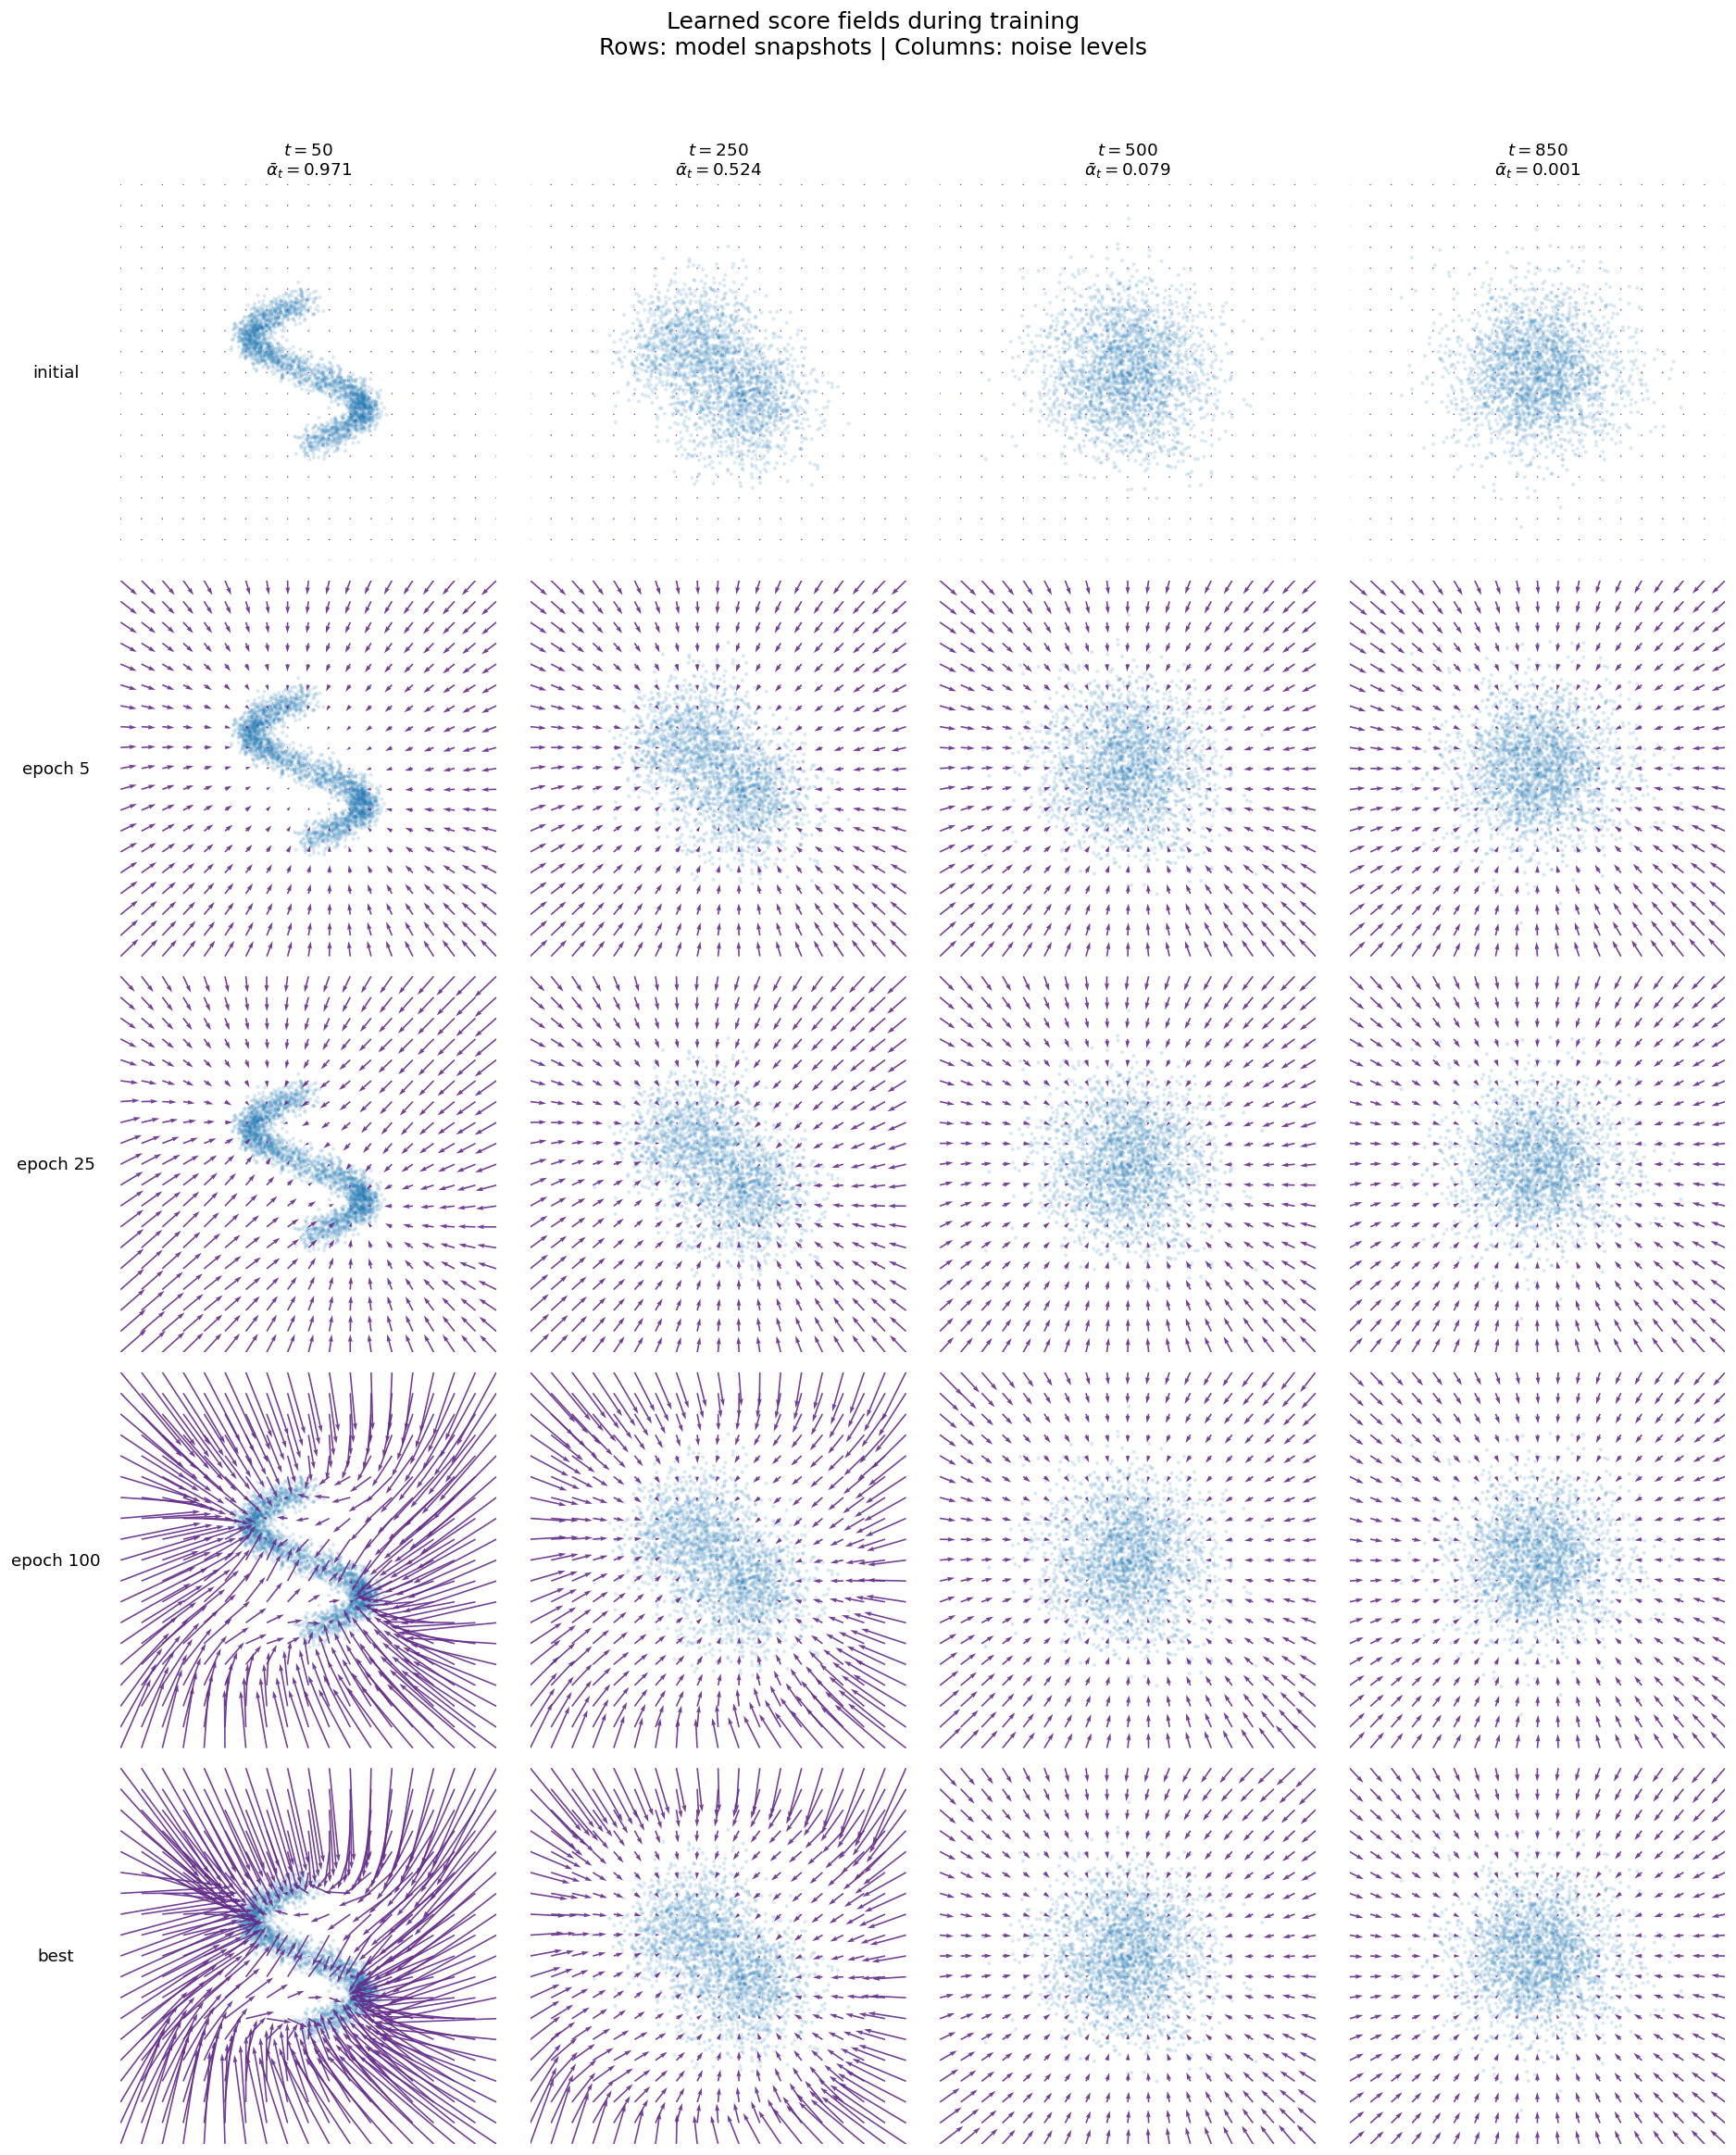

Saved score-field comparison to:
/Users/tiam/github/tiamheydari.github.io/_teaching/Modern_AI/notebooks/Workshop_E.4_diffusion_II/figures_diffusion_mlp/08_learned_score_fields_during_training.png


In [39]:

def plot_score_field_snapshots(
    snapshot_store: dict,
    snapshot_names: list[str],
    time_values: list[int],
    field_limit: float = FIELD_LIMIT,
    grid_size: int = FIELD_GRID_SIZE,
    quiver_scale: float = SCORE_QUIVER_SCALE,
    arrow_color: str = "#632C8A",
    save_name: str = "08_learned_score_fields_during_training.png",
):
    """
    Plot learned score fields.

    Rows correspond to model snapshots, such as:
        initial, epoch_25, epoch_100, best

    Columns correspond to diffusion noise levels t.

    The noisy cloud at each t is identical across all rows.

    Parameters
    ----------
    arrow_color : str
        Color used for score-field arrows.
        Default: "#632C8A".
    """
    if len(snapshot_names) == 0:
        raise ValueError("snapshot_names cannot be empty.")

    if len(time_values) == 0:
        raise ValueError("time_values cannot be empty.")

    missing_snapshots = [
        name for name in snapshot_names
        if name not in snapshot_store
    ]

    if missing_snapshots:
        available = ", ".join(snapshot_store.keys())
        raise KeyError(
            f"Unknown snapshots: {missing_snapshots}. "
            f"Available snapshots are: {available}"
        )

    for t_value in time_values:
        if t_value < 1 or t_value > T:
            raise ValueError(
                f"All time values must lie in {{1, ..., {T}}}."
            )

    grid_axis = np.linspace(
        -field_limit,
        field_limit,
        grid_size,
    )

    xx, yy = np.meshgrid(grid_axis, grid_axis)

    n_rows = len(snapshot_names)
    n_cols = len(time_values)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.0 * n_cols, 3.8 * n_rows),
        squeeze=False,
    )

    for row, snapshot_name in enumerate(snapshot_names):
        snapshot_model = build_model_from_state_dict(
            snapshot_store[snapshot_name]
        )

        for col, t_value in enumerate(time_values):
            ax = axes[row, col]

            noisy_cloud = make_fixed_noisy_cloud(t_value)

            u, v = predict_score_on_grid(
                model=snapshot_model,
                t_value=t_value,
                xx=xx,
                yy=yy,
            )

            ax.scatter(
                noisy_cloud[:, 0],
                noisy_cloud[:, 1],
                s=6,
                alpha=0.16,
                edgecolors="none",
                rasterized=True,
            )

            ax.quiver(
                xx,
                yy,
                u,
                v,
                angles="xy",
                scale_units="xy",
                scale=quiver_scale,
                width=0.004,
                alpha=0.9,
                color=arrow_color,
            )

            ax.set_xlim(-field_limit, field_limit)
            ax.set_ylim(-field_limit, field_limit)
            ax.set_aspect("equal", adjustable="box")

            ax.set_xticks([])
            ax.set_yticks([])

            for spine in ax.spines.values():
                spine.set_visible(False)

            alpha_bar_value = ALPHA_BAR[t_value].detach().cpu().item()

            if row == 0:
                ax.set_title(
                    rf"$t={t_value}$"
                    + "\n"
                    + rf"$\bar{{\alpha}}_t={alpha_bar_value:.3f}$",
                    fontsize=11,
                )

            if col == 0:
                ax.set_ylabel(
                    snapshot_name.replace("_", " "),
                    rotation=0,
                    labelpad=42,
                    va="center",
                    fontsize=11,
                )

        del snapshot_model

    fig.suptitle(
        "Learned score fields during training\n"
        "Rows: model snapshots | Columns: noise levels",
        y=1.02,
        fontsize=15,
    )

    plt.tight_layout()

    save_path = FIG_DIR / save_name
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    print(f"Saved score-field comparison to:\n{save_path.resolve()}")
    
plot_score_field_snapshots(
    snapshot_store=snapshot_states,
    snapshot_names=PLOT_SNAPSHOT_NAMES,
    time_values=PLOT_FIELD_TIMES,
    field_limit=FIELD_LIMIT,
    grid_size=FIELD_GRID_SIZE,
    quiver_scale=SCORE_QUIVER_SCALE,
)

# 10. Load the trained diffusion model

We now switch from training to generation.

During generation, we do not use clean training examples or score targets. We only need:

- the trained score neural network;

$$
s_\theta(x_t,t)
\approx
\nabla_{x_t}\log p_t(x_t)
$$

- the same forward noise schedule used during training;

$$
\{\beta_t\}_{t=1}^{T}
$$

- the data-standardization statistics used before training;

$$
\mu_{\mathrm{train}},
\qquad
\sigma_{\mathrm{train}}
$$

We will first generate points in the standardized coordinate system.

Later, after the reverse process reaches:

$$
x_0^{\mathrm{new}}
$$

we can transform generated points back to the original S-shape coordinate system:

$$
x_{\mathrm{original}}^{\mathrm{new}}
=
x_0^{\mathrm{new}}
\odot
\sigma_{\mathrm{train}}
+
\mu_{\mathrm{train}}
$$

We also choose the number of reverse solver steps:

$$
K
$$

For this first implementation, we use:

$$
K=T
$$

so that one reverse Euler--Maruyama step corresponds to one forward noise level.

Later, we can decrease $K$ to investigate whether fewer reverse steps still generate good samples.

In [29]:
# ── 10. Load the trained diffusion model ──────────────────────────────────────

# =============================================================================
# 10.1 Load the best checkpoint from training
# =============================================================================

if not BEST_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Could not find the trained-model checkpoint:\n{BEST_CHECKPOINT_PATH.resolve()}\n\n"
        "Run Section 8 / Section 9 training first."
    )

checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=DEVICE,
)

required_keys = {
    "epoch",
    "model_state_dict",
    "model_config",
    "diffusion_config",
    "data_standardization",
}

missing_keys = required_keys.difference(checkpoint.keys())

if missing_keys:
    raise KeyError(
        "The checkpoint is missing required entries: "
        f"{sorted(missing_keys)}"
    )


# =============================================================================
# 10.2 Rebuild and load the trained score network
# =============================================================================

model_config = checkpoint["model_config"]

score_model = ScoreMLP(
    hidden_dim=model_config["hidden_dim"],
    n_hidden_layers=model_config["n_hidden_layers"],
    num_timesteps=model_config["num_timesteps"],
).to(device=DEVICE, dtype=DTYPE)

score_model.load_state_dict(checkpoint["model_state_dict"])
score_model.eval()


# =============================================================================
# 10.3 Reload the exact forward noise schedule used during training
# =============================================================================

diffusion_config = checkpoint["diffusion_config"]

T = int(diffusion_config["T"])

BETA = torch.as_tensor(
    diffusion_config["beta_schedule"],
    dtype=DTYPE,
    device=DEVICE,
).clone()

if BETA.ndim != 1 or len(BETA) != T + 1:
    raise ValueError(
        "The saved beta schedule must have shape (T + 1,). "
        f"Expected ({T + 1},), but received {tuple(BETA.shape)}."
    )

if not torch.isclose(BETA[0], torch.tensor(0.0, device=DEVICE, dtype=DTYPE)):
    raise ValueError(
        "Expected BETA[0] = 0 because t = 0 corresponds to clean data."
    )

ALPHA = 1.0 - BETA
ALPHA[0] = 1.0

ALPHA_BAR = torch.cumprod(ALPHA, dim=0)

ONE_MINUS_ALPHA_BAR = 1.0 - ALPHA_BAR

SQRT_ALPHA_BAR = torch.sqrt(ALPHA_BAR)

SQRT_ONE_MINUS_ALPHA_BAR = torch.sqrt(
    torch.clamp(
        ONE_MINUS_ALPHA_BAR,
        min=0.0,
    )
)


# =============================================================================
# 10.4 Reload data-standardization statistics
# =============================================================================

DATA_MEAN = np.asarray(
    checkpoint["data_standardization"]["mean"],
    dtype=np.float32,
).reshape(1, 2)

DATA_STD = np.asarray(
    checkpoint["data_standardization"]["std"],
    dtype=np.float32,
).reshape(1, 2)

if np.any(DATA_STD <= 0):
    raise ValueError(
        "The saved data standard deviations must be strictly positive."
    )


# =============================================================================
# 10.5 Choose the reverse solver resolution
# =============================================================================

# Start with K = T:
# one reverse Euler--Maruyama step for every forward noise level.
#
# Later, try smaller values such as:
# K_REVERSE = 500
# K_REVERSE = 250
# K_REVERSE = 100

K_REVERSE = T

if K_REVERSE < 1:
    raise ValueError("K_REVERSE must be at least 1.")

DELTA_T_REVERSE = T / K_REVERSE


# =============================================================================
# 10.6 Print the loaded generation configuration
# =============================================================================

print("Loaded trained diffusion model")
print("-" * 45)

print(f"Best checkpoint epoch : {checkpoint['epoch']}")
print(f"Validation loss       : {checkpoint['valid_loss']:.6f}")

print("\nScore network")
print(f"  Hidden dimension    : {model_config['hidden_dim']}")
print(f"  Hidden layers       : {model_config['n_hidden_layers']}")
print(f"  Output              : 2D score vector")

print("\nForward diffusion schedule")
print(f"  T                   : {T}")
print(f"  beta_1              : {BETA[1].item():.6f}")
print(f"  beta_T              : {BETA[T].item():.6f}")
print(f"  alpha_bar_T         : {ALPHA_BAR[T].item():.8f}")

print("\nReverse solver")
print(f"  K                   : {K_REVERSE}")
print(f"  Delta t             : {DELTA_T_REVERSE:.6f}")

print("\nOriginal-data normalization")
print(f"  Mean                : {DATA_MEAN.ravel()}")
print(f"  Standard deviation  : {DATA_STD.ravel()}")

print(f"\nDevice                : {DEVICE}")

Loaded trained diffusion model
---------------------------------------------
Best checkpoint epoch : 159
Validation loss       : 0.329041

Score network
  Hidden dimension    : 128
  Hidden layers       : 3
  Output              : 2D score vector

Forward diffusion schedule
  T                   : 1000
  beta_1              : 0.000100
  beta_T              : 0.020000
  alpha_bar_T         : 0.00004036

Reverse solver
  K                   : 1000
  Delta t             : 1.000000

Original-data normalization
  Mean                : [ 0.01503802 -0.00724491]
  Standard deviation  : [0.8167903 0.7790838]

Device                : mps


## Sanity-check the loaded score model

The trained score network receives a noisy point and a noise level:

$$
(x_t,t)
$$

and returns a two-dimensional score vector:

$$
s_\theta(x_t,t)
\in
\mathbb R^2
$$

At this stage, we only verify that the checkpoint loaded correctly and that the model produces finite score vectors.

In [30]:
# ── Sanity-check the loaded score model ───────────────────────────────────────

x_demo = torch.tensor(
    [
        [0.0, 0.0],
        [1.0, -1.0],
        [-2.0, 1.5],
    ],
    dtype=DTYPE,
    device=DEVICE,
)

t_demo = torch.tensor(
    [
        1,
        T // 2,
        T,
    ],
    dtype=torch.long,
    device=DEVICE,
)

with torch.no_grad():
    score_demo = score_model(x_demo, t_demo)

print("Input noisy points:")
print(x_demo.detach().cpu().numpy())

print("\nNoise levels:")
print(t_demo.detach().cpu().numpy())

print("\nPredicted score vectors:")
print(score_demo.detach().cpu().numpy())

if score_demo.shape != x_demo.shape:
    raise RuntimeError(
        "The loaded score model should output one 2D vector for every 2D point."
    )

if not torch.isfinite(score_demo).all():
    raise RuntimeError(
        "The loaded score model produced non-finite score values."
    )

print("\nCheckpoint and score model loaded successfully.")

Input noisy points:
[[ 0.   0. ]
 [ 1.  -1. ]
 [-2.   1.5]]

Noise levels:
[   1  500 1000]

Predicted score vectors:
[[ 0.17359316 -2.0546072 ]
 [-0.9726928   0.92314893]
 [ 1.9869412  -1.5385047 ]]

Checkpoint and score model loaded successfully.


# 11. Start from pure noise

The forward process was designed so that, at the final noise level:

$$
p_T(x)
\approx
\mathcal N(0,I)
$$

This is why we can start generation from pure Gaussian noise.

To generate $M$ new samples, we draw a batch of independent starting points:

$$
X_T^{\mathrm{new}}
=
\left\{
x_T^{\mathrm{new},(m)}
\right\}_{m=1}^{M}
$$

where:

$$
x_T^{\mathrm{new},(m)}
\sim
\mathcal N(0,I)
$$

Each row of this batch is the initial point for one new sample.

At this point, these points have no S-shaped structure. They are simply random points from a standard Gaussian cloud.

The learned reverse SDE will gradually transform them into data-like samples.

In [31]:
# ── 11. Start from pure Gaussian noise ────────────────────────────────────────

# Number of new samples to generate in parallel.
N_NEW_SAMPLES = 3_000

# We will later use this particular initial point when visualizing one
# reverse-generation trajectory.
TRAJECTORY_SAMPLE_INDEX = 0

# Separate seed for reproducible generation.
GENERATION_SEED = SEED + 1_000

if N_NEW_SAMPLES < 1:
    raise ValueError("N_NEW_SAMPLES must be at least 1.")

if not 0 <= TRAJECTORY_SAMPLE_INDEX < N_NEW_SAMPLES:
    raise ValueError(
        "TRAJECTORY_SAMPLE_INDEX must be between 0 and N_NEW_SAMPLES - 1."
    )

# Create Gaussian noise on CPU first, then move it to the selected device.
# This keeps the random generator compatible with CPU, CUDA, and MPS devices.
generation_rng = torch.Generator(device="cpu")
generation_rng.manual_seed(GENERATION_SEED)

x_T_new = torch.randn(
    size=(N_NEW_SAMPLES, 2),
    generator=generation_rng,
    dtype=DTYPE,
    device="cpu",
).to(DEVICE)

# Keep an unchanged copy of the original Gaussian cloud.
# Section 12 will use this as the starting point for reverse generation.
x_T_new_initial = x_T_new.clone()

if x_T_new.shape != (N_NEW_SAMPLES, 2):
    raise RuntimeError(
        "Expected the initial noise batch to have shape "
        f"({N_NEW_SAMPLES}, 2), but received {tuple(x_T_new.shape)}."
    )

if not torch.isfinite(x_T_new).all():
    raise RuntimeError("The initial Gaussian noise contains non-finite values.")

print(f"Initial noise batch shape : {tuple(x_T_new.shape)}")
print(f"Initial noise batch device: {x_T_new.device}")

print("\nEmpirical Gaussian-cloud statistics")
print(f"  Mean: {x_T_new.mean(dim=0).detach().cpu().numpy()}")
print(f"  Std : {x_T_new.std(dim=0).detach().cpu().numpy()}")

print(
    f"\nTrajectory starting point "
    f"x_T_new[{TRAJECTORY_SAMPLE_INDEX}]:"
)
print(
    x_T_new[TRAJECTORY_SAMPLE_INDEX].detach().cpu().numpy()
)

Initial noise batch shape : (3000, 2)
Initial noise batch device: mps:0

Empirical Gaussian-cloud statistics
  Mean: [-0.00308347 -0.00390775]
  Std : [1.01831    0.98666126]

Trajectory starting point x_T_new[0]:
[-0.6346693   0.22594817]


## Visualize the initial Gaussian cloud

The left panel shows the terminal cloud obtained by applying the forward process to real S-shaped data until:

$$
t=T
$$

The right panel shows newly sampled Gaussian starting points:

$$
x_T^{\mathrm{new}}
\sim
\mathcal N(0,I)
$$

These clouds should look similar because:

$$
p_T(x)
\approx
\mathcal N(0,I)
$$

The left panel uses training data only as a visual reference.

The actual generation procedure uses only the pure Gaussian cloud in the right panel.

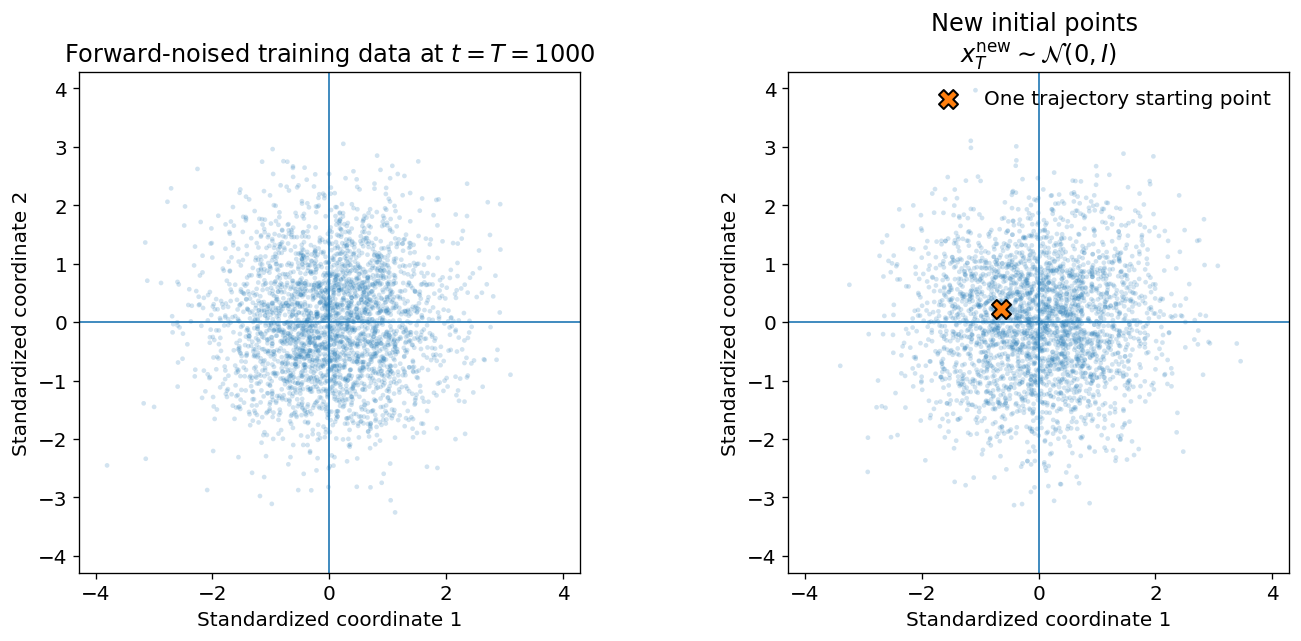

In [32]:
# ── Visualize terminal forward noise versus new Gaussian starting points ───────

N_REFERENCE_POINTS = min(N_NEW_SAMPLES, len(data_train))

reference_rng = np.random.default_rng(SEED + 1_001)

reference_indices = reference_rng.choice(
    len(data_train),
    size=N_REFERENCE_POINTS,
    replace=False,
)

x0_reference = torch.from_numpy(
    data_train[reference_indices]
).to(
    device=DEVICE,
    dtype=DTYPE,
)

# Create a noisy cloud from real data at the terminal forward time t = T.
forward_noise_rng = torch.Generator(device="cpu")
forward_noise_rng.manual_seed(SEED + 1_002)

eps_terminal = torch.randn(
    size=x0_reference.shape,
    generator=forward_noise_rng,
    dtype=DTYPE,
    device="cpu",
).to(DEVICE)

t_terminal = torch.full(
    size=(N_REFERENCE_POINTS,),
    fill_value=T,
    dtype=torch.long,
    device=DEVICE,
)

with torch.no_grad():
    x_T_from_data, _ = q_sample(
        x0=x0_reference,
        t=t_terminal,
        eps=eps_terminal,
    )

x_T_from_data_np = x_T_from_data.detach().cpu().numpy()
x_T_new_np = x_T_new.detach().cpu().numpy()

# Use common axes so the two clouds can be compared directly.
all_points = np.vstack([x_T_from_data_np, x_T_new_np])

max_abs_coordinate = np.abs(all_points).max()
plot_limit = max(4.0, 1.08 * max_abs_coordinate)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

axes[0].scatter(
    x_T_from_data_np[:, 0],
    x_T_from_data_np[:, 1],
    s=8,
    alpha=0.20,
    edgecolors="none",
    rasterized=True,
)

axes[0].axhline(0, linewidth=1)
axes[0].axvline(0, linewidth=1)

axes[0].set_xlim(-plot_limit, plot_limit)
axes[0].set_ylim(-plot_limit, plot_limit)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlabel("Standardized coordinate 1")
axes[0].set_ylabel("Standardized coordinate 2")
axes[0].set_title(
    rf"Forward-noised training data at $t=T={T}$"
)

axes[1].scatter(
    x_T_new_np[:, 0],
    x_T_new_np[:, 1],
    s=8,
    alpha=0.20,
    edgecolors="none",
    rasterized=True,
)

# Highlight the initial point whose reverse trajectory we will later track.
trajectory_start = x_T_new_np[TRAJECTORY_SAMPLE_INDEX]

axes[1].scatter(
    trajectory_start[0],
    trajectory_start[1],
    marker="X",
    s=130,
    linewidths=1.2,
    edgecolors="black",
    label="One trajectory starting point",
)

axes[1].axhline(0, linewidth=1)
axes[1].axvline(0, linewidth=1)

axes[1].set_xlim(-plot_limit, plot_limit)
axes[1].set_ylim(-plot_limit, plot_limit)
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_xlabel("Standardized coordinate 1")
axes[1].set_ylabel("Standardized coordinate 2")
axes[1].set_title(
    r"New initial points "
    + "\n"
    + r"$x_T^{\mathrm{new}} \sim \mathcal{N}(0,I)$"
)

axes[1].legend(frameon=False, loc="upper right")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "09_generation_initial_gaussian_cloud.png",
    bbox_inches="tight",
)

plt.show()

# 12. Run the learned reverse SDE

We now transform the Gaussian starting points into new data-like samples.

For this first implementation, we use one reverse Euler--Maruyama step for every forward noise level:

$$
K=T
$$

Therefore:

$$
\Delta t = 1
$$

Starting from:

$$
x_T^{\mathrm{new}}
\sim
\mathcal N(0,I)
$$

we move backward through the noise levels:

$$
t=T,T-1,\ldots,1
$$

At each reverse step, the trained neural network predicts the score:

$$
s_\theta
\left(
x_t^{\mathrm{new}},t
\right)
$$

Then we apply the reverse VP-SDE Euler--Maruyama update:

$$
x_{t-1}^{\mathrm{new}}
=
x_t^{\mathrm{new}}
+
\left[
\frac{1}{2}\beta_t x_t^{\mathrm{new}}
+
\beta_t
s_\theta
\left(
x_t^{\mathrm{new}},t
\right)
\right]
+
\sqrt{\beta_t}\,z_t
$$

where:

$$
z_t
\sim
\mathcal N(0,I)
$$

The first term reverses the forward pull toward the origin.

The second term uses the learned score field to guide the point toward more data-like regions.

The final term adds the random fluctuation required by the reverse SDE.

For the final step, from $t=1$ to $t=0$, we optionally set:

$$
z_1=0
$$

so that we do not add fresh random noise immediately before returning the generated sample.

In [33]:
# ── 12. Run the learned reverse VP-SDE ────────────────────────────────────────

# This first sampler uses one reverse step per trained noise level.
#
# For K_REVERSE < T, we would need a separate reduced-step implementation that
# carefully handles larger reverse time intervals. For now, use the full grid.

if K_REVERSE != T:
    raise ValueError(
        "This first reverse Euler--Maruyama sampler requires K_REVERSE = T. "
        "Set K_REVERSE = T in Section 10."
    )

if DELTA_T_REVERSE != 1:
    raise ValueError(
        "With K_REVERSE = T, DELTA_T_REVERSE must equal 1."
    )


# ── Generation settings ───────────────────────────────────────────────────────

# Reverse times at which we save snapshots of the full generated cloud.
REVERSE_SNAPSHOT_TIMES = [
    T,
    int(0.75 * T),
    int(0.50 * T),
    int(0.25 * T),
    0,
]

# Which individual generated points should have their full reverse trajectories
# recorded for later visualization?
TRACK_SAMPLE_INDICES = [0, 1, 2]

# At the final step t = 1 -> 0, do not add new stochastic noise.
ADD_NOISE_AT_FINAL_STEP = False

# Separate random seed for the reverse SDE noise.
REVERSE_SDE_SEED = SEED + 2_000


def sample_standard_normal_like(
    x: torch.Tensor,
    generator: torch.Generator,
) -> torch.Tensor:
    """
    Sample standard Gaussian noise with the same shape as x.

    Noise is generated on CPU first so this works consistently with
    CPU, CUDA, and MPS devices.
    """
    noise_cpu = torch.randn(
        size=x.shape,
        generator=generator,
        dtype=x.dtype,
        device="cpu",
    )

    return noise_cpu.to(x.device)


@torch.no_grad()
def reverse_em_sample(
    model: nn.Module,
    x_T: torch.Tensor,
    snapshot_times: list[int] | None = None,
    trajectory_indices: list[int] | None = None,
    add_noise_at_final_step: bool = False,
    generator: torch.Generator | None = None,
):
    """
    Generate samples by integrating the learned reverse VP-SDE.

    With K_REVERSE = T and Delta t = 1, the reverse update is:

        x_(t-1)
        =
        x_t
        +
        [0.5 * beta_t * x_t + beta_t * s_theta(x_t, t)]
        +
        sqrt(beta_t) * z_t

    Parameters
    ----------
    model : nn.Module
        Trained score model s_theta(x_t, t).

    x_T : torch.Tensor, shape (N, 2)
        Initial Gaussian noise samples.

    snapshot_times : list[int] or None
        Times t at which the complete generated cloud x_t is saved.

    trajectory_indices : list[int] or None
        Indices of selected samples whose full reverse trajectories are saved.

    add_noise_at_final_step : bool
        If False, sets z_1 = 0 for the final step from t = 1 to t = 0.

    generator : torch.Generator or None
        Random generator used for reverse-SDE noise.

    Returns
    -------
    x_0 : torch.Tensor, shape (N, 2)
        Final generated samples in standardized coordinates.

    snapshots : dict[int, np.ndarray]
        Saved generated clouds at requested reverse times.

    trajectory_times : np.ndarray, shape (T + 1,)
        Reverse times corresponding to the stored trajectories.

    trajectories : np.ndarray, shape (T + 1, n_tracks, 2)
        Full reverse paths for selected generated samples.
    """
    if x_T.ndim != 2 or x_T.shape[1] != 2:
        raise ValueError(
            "x_T must have shape (N, 2), "
            f"but received {tuple(x_T.shape)}."
        )

    if not torch.is_floating_point(x_T):
        raise TypeError("x_T must be a floating-point tensor.")

    if generator is None:
        generator = torch.Generator(device="cpu")
        generator.manual_seed(REVERSE_SDE_SEED)

    n_samples = x_T.shape[0]

    if snapshot_times is None:
        snapshot_times = [T, 0]

    snapshot_times = sorted(
        {
            int(t_value)
            for t_value in snapshot_times
        },
        reverse=True,
    )

    for t_value in snapshot_times:
        if t_value < 0 or t_value > T:
            raise ValueError(
                f"All snapshot times must lie in {{0, ..., {T}}}."
            )

    snapshot_times_set = set(snapshot_times)

    if trajectory_indices is None:
        trajectory_indices = []

    trajectory_indices = [int(index) for index in trajectory_indices]

    if len(set(trajectory_indices)) != len(trajectory_indices):
        raise ValueError("trajectory_indices must not contain duplicates.")

    for index in trajectory_indices:
        if index < 0 or index >= n_samples:
            raise ValueError(
                f"Trajectory index {index} is outside the valid range "
                f"[0, {n_samples - 1}]."
            )

    x = x_T.clone().to(device=DEVICE, dtype=DTYPE)

    model.eval()

    snapshots = {}

    if T in snapshot_times_set:
        snapshots[T] = x.detach().cpu().numpy().copy()

    if len(trajectory_indices) > 0:
        trajectory_points = [
            x[trajectory_indices].detach().cpu().numpy().copy()
        ]
    else:
        trajectory_points = []

    # Move from t = T down to t = 1.
    #
    # After each update, x represents x_(t-1).
    for t_value in range(T, 0, -1):
        t_batch = torch.full(
            size=(n_samples,),
            fill_value=t_value,
            dtype=torch.long,
            device=DEVICE,
        )

        beta_t = BETA[t_value]

        predicted_score = model(x, t_batch)

        reverse_drift = (
            0.5 * beta_t * x
            + beta_t * predicted_score
        )

        if t_value == 1 and not add_noise_at_final_step:
            z_t = torch.zeros_like(x)
        else:
            z_t = sample_standard_normal_like(
                x=x,
                generator=generator,
            )

        x = (
            x
            + reverse_drift
            + torch.sqrt(beta_t) * z_t
        )

        new_time = t_value - 1

        if new_time in snapshot_times_set:
            snapshots[new_time] = x.detach().cpu().numpy().copy()

        if len(trajectory_indices) > 0:
            trajectory_points.append(
                x[trajectory_indices].detach().cpu().numpy().copy()
            )

    if not torch.isfinite(x).all():
        raise RuntimeError(
            "The reverse sampler produced non-finite generated values."
        )

    trajectory_times = np.arange(T, -1, -1)

    if len(trajectory_points) > 0:
        trajectories = np.stack(
            trajectory_points,
            axis=0,
        )
    else:
        trajectories = np.empty(
            shape=(T + 1, 0, 2),
            dtype=np.float32,
        )

    return x, snapshots, trajectory_times, trajectories

## Generate new samples

We now start with the Gaussian cloud created in Section 11:

$$
x_T^{\mathrm{new}}
\sim
\mathcal N(0,I)
$$

and repeatedly apply the learned reverse update until we reach:

$$
x_0^{\mathrm{new}}
$$

The sampler returns generated points in standardized coordinates.

We then transform them back to the original coordinate system:

$$
x_{\mathrm{original}}^{\mathrm{new}}
=
x_0^{\mathrm{new}}
\odot
\sigma_{\mathrm{train}}
+
\mu_{\mathrm{train}}
$$

In [34]:
# ── Generate new samples with the learned reverse SDE ─────────────────────────

REVERSE_SNAPSHOT_TIMES = sorted(
    {
        int(t_value)
        for t_value in REVERSE_SNAPSHOT_TIMES
    },
    reverse=True,
)

reverse_rng = torch.Generator(device="cpu")
reverse_rng.manual_seed(REVERSE_SDE_SEED)

x_0_new_standardized, reverse_snapshots, reverse_times, reverse_trajectories = (
    reverse_em_sample(
        model=score_model,
        x_T=x_T_new_initial,
        snapshot_times=REVERSE_SNAPSHOT_TIMES,
        trajectory_indices=TRACK_SAMPLE_INDICES,
        add_noise_at_final_step=ADD_NOISE_AT_FINAL_STEP,
        generator=reverse_rng,
    )
)

# Convert generated standardized samples back to the original S-shape coordinates.
x_0_new_original = (
    x_0_new_standardized.detach().cpu().numpy() * DATA_STD
    + DATA_MEAN
)

print(f"Generated standardized samples shape: {tuple(x_0_new_standardized.shape)}")
print(f"Generated original-coordinate shape : {x_0_new_original.shape}")

print("\nSaved reverse snapshots:")
for time_value in sorted(reverse_snapshots.keys(), reverse=True):
    print(f"  t = {time_value}")

print(f"\nTracked trajectories: {reverse_trajectories.shape[1]}")
print(f"Trajectory array shape: {reverse_trajectories.shape}")

print("\nGenerated-sample statistics in standardized coordinates")
print(
    f"  Mean: "
    f"{x_0_new_standardized.mean(dim=0).detach().cpu().numpy()}"
)
print(
    f"  Std : "
    f"{x_0_new_standardized.std(dim=0).detach().cpu().numpy()}"
)

Generated standardized samples shape: (3000, 2)
Generated original-coordinate shape : (3000, 2)

Saved reverse snapshots:
  t = 1000
  t = 750
  t = 500
  t = 250
  t = 0

Tracked trajectories: 3
Trajectory array shape: (1001, 3, 2)

Generated-sample statistics in standardized coordinates
  Mean: [ 0.09291052 -0.12717837]
  Std : [1.00076   0.9895618]


## Visualize the reverse generation process

Each panel shows the entire generated cloud at one reverse time.

At the beginning:

$$
t=T
$$

the cloud is Gaussian noise.

As time decreases, the learned score field guides the cloud toward the S-shaped data distribution.

At the end:

$$
t=0
$$

the cloud should resemble a new sample from the original data distribution.

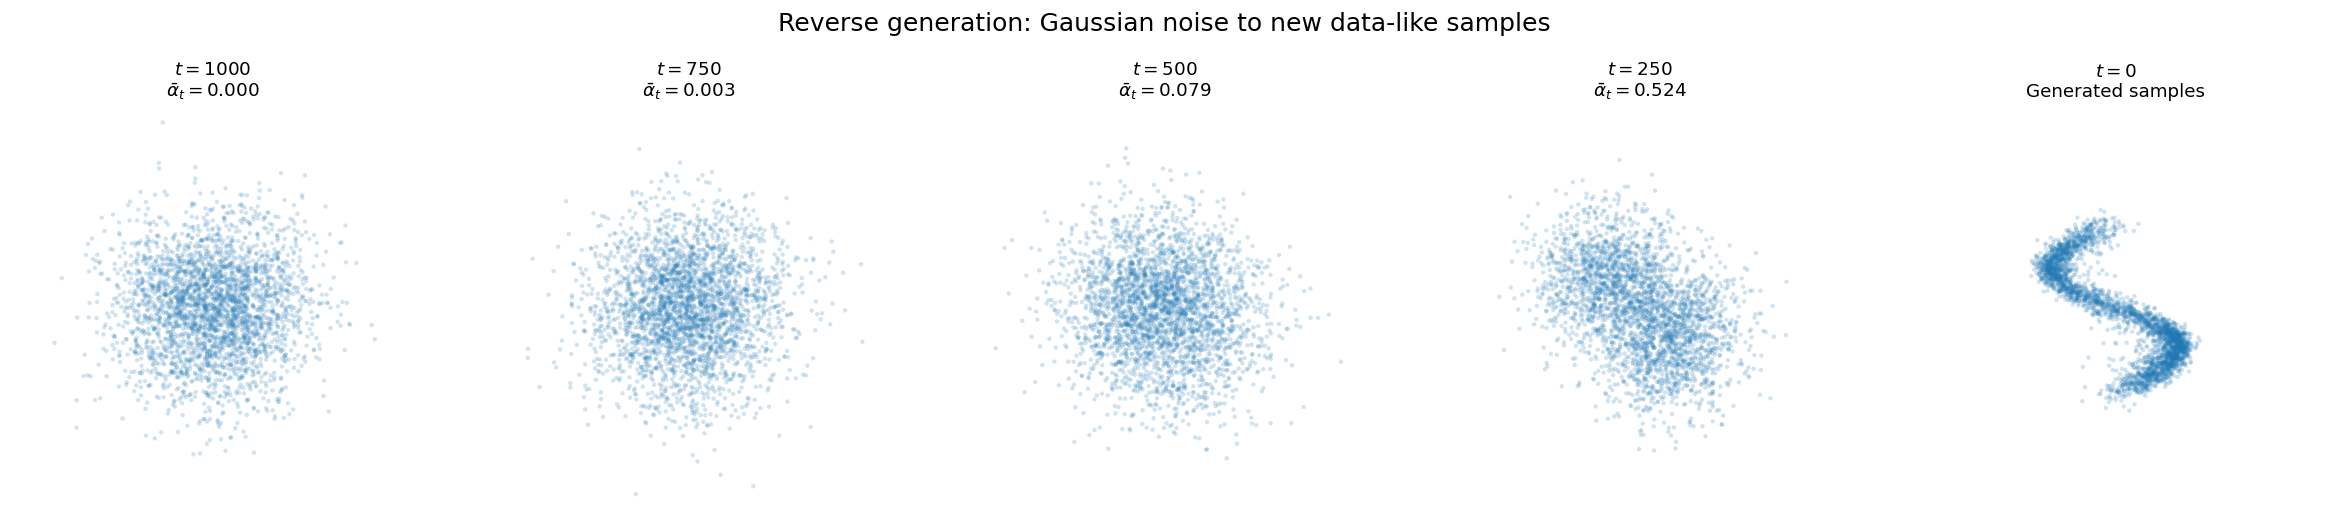

In [35]:
# ── Visualize reverse-generation snapshots in standardized coordinates ────────

snapshot_times_to_plot = sorted(
    reverse_snapshots.keys(),
    reverse=True,
)

all_reverse_points = np.vstack(
    [
        reverse_snapshots[t_value]
        for t_value in snapshot_times_to_plot
    ]
)

max_abs_coordinate = np.abs(all_reverse_points).max()
plot_limit = max(4.0, 1.08 * max_abs_coordinate)

fig, axes = plt.subplots(
    1,
    len(snapshot_times_to_plot),
    figsize=(4.0 * len(snapshot_times_to_plot), 4.2),
)

if len(snapshot_times_to_plot) == 1:
    axes = [axes]

for ax, t_value in zip(axes, snapshot_times_to_plot):
    points = reverse_snapshots[t_value]

    ax.scatter(
        points[:, 0],
        points[:, 1],
        s=7,
        alpha=0.20,
        edgecolors="none",
        rasterized=True,
    )

    ax.set_xlim(-plot_limit, plot_limit)
    ax.set_ylim(-plot_limit, plot_limit)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    if t_value == 0:
        title = r"$t=0$" + "\n" + "Generated samples"
    else:
        alpha_bar_value = ALPHA_BAR[t_value].item()

        title = (
            rf"$t={t_value}$"
            + "\n"
            + rf"$\bar{{\alpha}}_t={alpha_bar_value:.3f}$"
        )

    ax.set_title(title, fontsize=11)

fig.suptitle(
    "Reverse generation: Gaussian noise to new data-like samples",
    y=1.03,
    fontsize=15,
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "10_reverse_generation_snapshots.png",
    bbox_inches="tight",
)

plt.show()

## Compare generated samples with the original S-shaped data

The final generated points are transformed back to the original coordinate system.

We compare:

$$
x_0^{\mathrm{new}}
$$

with held-out real test data.

The generated points should reproduce the global S-shaped distribution, without copying individual training points.

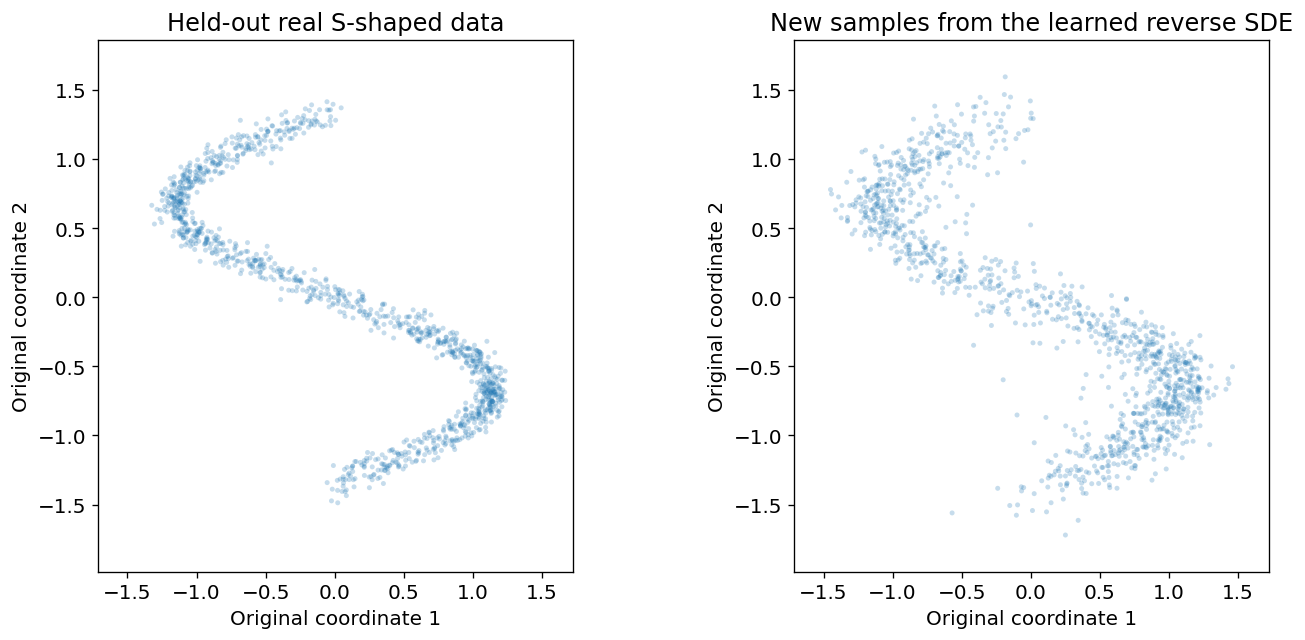

In [37]:
# ── Compare generated samples with held-out real data ─────────────────────────

N_COMPARE = min(
    len(data_test_raw),
    len(x_0_new_original),
)

compare_rng = np.random.default_rng(SEED + 2_001)

real_indices = compare_rng.choice(
    len(data_test_raw),
    size=N_COMPARE,
    replace=False,
)

generated_indices = compare_rng.choice(
    len(x_0_new_original),
    size=N_COMPARE,
    replace=False,
)

real_points = data_test_raw[real_indices]
generated_points = x_0_new_original[generated_indices]

all_original_points = np.vstack(
    [
        real_points,
        generated_points,
    ]
)

x_min, y_min = all_original_points.min(axis=0)
x_max, y_max = all_original_points.max(axis=0)

padding = 0.08 * max(
    x_max - x_min,
    y_max - y_min,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

axes[0].scatter(
    real_points[:, 0],
    real_points[:, 1],
    s=9,
    alpha=0.25,
    edgecolors="none",
    rasterized=True,
)

axes[0].set_xlim(x_min - padding, x_max + padding)
axes[0].set_ylim(y_min - padding, y_max + padding)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlabel("Original coordinate 1")
axes[0].set_ylabel("Original coordinate 2")
axes[0].set_title("Held-out real S-shaped data")

axes[1].scatter(
    generated_points[:, 0],
    generated_points[:, 1],
    s=9,
    alpha=0.25,
    edgecolors="none",
    rasterized=True,
)

axes[1].set_xlim(x_min - padding, x_max + padding)
axes[1].set_ylim(y_min - padding, y_max + padding)
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_xlabel("Original coordinate 1")
axes[1].set_ylabel("Original coordinate 2")
axes[1].set_title("New samples from the learned reverse SDE")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "11_real_vs_generated_samples.png",
    bbox_inches="tight",
)

plt.show()